# RL Network-Markowitz Portfolio Optimization
### Thesis-Ready Version (Fixed v5) — Multi-Seed SAC + Ablation Study + XAI Analysis

**Ringkasan perbaikan dari versi sebelumnya (v4 → v5):**
- Duplikasi definisi fungsi dihapus (tiap fungsi hanya didefinisikan sekali)
- Cache key diubah ke tuple `('train', i)` / `('test', i)` agar tidak collision
- `compute_market_features`: parameter `port_val` yang tidak dipakai dihapus
- `_solve_weights`: menambahkan `warnings.warn` saat fallback ke equal-weight
- `get_obs_dim` & `build_observation`: konsisten — raise `ValueError` jika keduanya False
- `AblationPortfolioEnv`: `_rew_stats` di-reset tiap `reset()` (bukan akumulasi lintas episode)
- `AblationPortfolioEnv`: parameter `split='train'/'test'` menggantikan `data_start_offset` integer
- `run_wilcoxon_tests` sekarang dipanggil di Final Analysis dan hasilnya ditampilkan
- Label `Features` di dashboard diperbaiki: `Network(2) + Market(7)` (bukan 5+4)
- `FEATURE_NAMES` dikelompokkan dengan komentar agar sesuai implementasi
- `plot_shap_analysis`: background & explain sample diperbesar; skip jika model None
- Judul notebook disesuaikan: CVaR adalah metrik evaluasi, bukan reward RL
- **[v4] Normalisasi konsisten: market features (7) kini di-Z-score dari statistik training,
  sama seperti network features — menghilangkan inkonsistensi skala antar feature group**

**[v5] Perbaikan fairness & validitas eksperimen:**
- **[FIX #1 — KRITIS] EvalCallback diganti menggunakan validation set terpisah**
  (10% dari data, antara training dan test), bukan test set. Mencegah model selection
  bias / look-ahead bias di mana model terbaik dipilih berdasarkan performa test set.
- **[FIX #2 — KRITIS] BuyHold bobot awal dari window terakhir training**, bukan dari
  window pertama test set. Menghilangkan data leakage di mana investor seolah sudah
  mengetahui distribusi aset di awal periode test.
- **[FIX #3 — MINOR] SET_REBALANCE kini digunakan** secara konsisten di transaction
  cost analysis (Section 13D). Sebelumnya variabel ini dideklarasikan tapi tidak dipakai.


## 1. Imports & Global Settings

In [1]:
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import networkx as nx
import seaborn as sns
import shap
import torch
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import SAC
from stable_baselines3.common.callbacks import BaseCallback, EvalCallback
from tqdm.notebook import tqdm
from scipy import stats
from scipy.optimize import minimize
from IPython.display import display

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

# ================================================================
# GLOBAL SETTINGS
# ================================================================
SEEDS         = [42, 123, 77]
TRAIN_STEPS   = 1000
FORCE_RETRAIN = True    # Set False jika model sudah ada
SET_WINDOW    = 30
SET_REBALANCE = 7
REWARD_WINDOW = 20
CVAR_LEVEL    = 0.95    # CVaR digunakan sebagai metrik evaluasi, bukan reward
STAT_ALPHA    = 0.05
SAVE_IMAGES   = False

ABLATION_CONFIGS = {
    'E2_Sharpe'          : {'use_network': True,  'use_market': True,  'reward_type': 'sharpe'},
    'E2_Sortino'         : {'use_network': True,  'use_market': True,  'reward_type': 'sortino'},
    'E2_Calmar'          : {'use_network': True,  'use_market': True,  'reward_type': 'calmar'},
    'E2_Ulcer'           : {'use_network': True,  'use_market': True,  'reward_type': 'ulcer'},
    'E2_Ensemble_Avg'    : {'use_network': True,  'use_market': True,  'is_ensemble': True},
    #'Comp_Static_Gamma0' : {'use_network': True,  'use_market': False, 'static_gamma': 0.0},
    #'Comp_Static_Gamma1' : {'use_network': True,  'use_market': False, 'static_gamma': 1.0},
    'Comp_Static_Gamma2' : {'use_network': True,  'use_market': False, 'static_gamma': 2.0},
    # Buy-and-Hold: gamma awal dihitung satu kali, tidak di-update tiap step
    'BuyHold_Markowitz'  : {'use_network': True,  'use_market': False, 'is_buyhold': True},
    'EqualWeight'        : {'is_equal_weight': True},
}

EVAL_METRICS = ['Sharpe Ratio', 'Sortino Ratio', 'Calmar Ratio', 'Ulcer Index']

SCRIPT_DIR = os.getcwd()
OUTPUT_DIR = os.path.join(SCRIPT_DIR, 'ablation_results_thesis')
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('Environment initialized.')
print(f'Output dir: {OUTPUT_DIR}')



Environment initialized.
Output dir: g:\My Drive\00_Kuliah\Thesis\sharpenThesis_dpInsya\guidici_reexperiment_clean2\ablation_results_thesis


## 2. Data Loading

In [2]:
file_data = 'crypto_data_real.xlsx'

def load_and_split(filename, train_split=0.7, val_split=0.1):
    """
    [v5] Split data menjadi 3 bagian temporal: train / validation / test.

    val_split diambil dari periode antara training dan test set (temporal order).
    Validation set dipakai HANYA untuk EvalCallback (model selection),
    bukan untuk evaluasi performa akhir.

    Default split: 70% train | 10% validation | 20% test (berdasarkan posisi temporal).
    """
    df = pd.read_excel(filename, sheet_name='Returns', index_col=0)
    df.index = pd.to_datetime(df.index)
    assets = list(df.columns)
    if 'USDT' in assets:
        assets.remove('USDT')
    assets.sort()
    df = df[assets]

    n = len(df)
    train_end = int(n * train_split)
    val_end   = int(n * (train_split + val_split))

    ret_train_ = df.iloc[:train_end]
    ret_val_   = df.iloc[train_end:val_end]   # [v5] validation set
    ret_test_  = df.iloc[val_end:]             # held-out test set

    return ret_train_, ret_val_, ret_test_, assets

ret_train, ret_val, ret_test, assets = load_and_split(file_data)

print(f'Assets    : {len(assets)} — {assets}')
print(f'Training  : {ret_train.index[0].date()} to {ret_train.index[-1].date()} ({len(ret_train)} rows)')
print(f'Validation: {ret_val.index[0].date()} to {ret_val.index[-1].date()} ({len(ret_val)} rows)  ← [v5] for EvalCallback only')
print(f'Testing   : {ret_test.index[0].date()} to {ret_test.index[-1].date()} ({len(ret_test)} rows)  ← held-out')
print()
print('[v5] Validation set digunakan HANYA untuk model selection (EvalCallback).')
print('     Test set TIDAK PERNAH dilihat selama training.')


Assets    : 9 — ['BCH', 'BNB', 'BTC', 'EOS', 'ETH', 'LTC', 'TRX', 'XLM', 'XRP']
Training  : 2017-09-15 to 2019-03-02 (534 rows)
Validation: 2019-03-03 to 2019-05-17 (76 rows)  ← [v5] for EvalCallback only
Testing   : 2019-05-18 to 2019-10-17 (153 rows)  ← held-out

[v5] Validation set digunakan HANYA untuk model selection (EvalCallback).
     Test set TIDAK PERNAH dilihat selama training.


## 3. Portfolio Optimization Logic

In [3]:
def apply_rmt_filter(returns_window):
    """Random Matrix Theory denoising filter pada correlation matrix."""
    T, N = returns_window.shape
    corr_mat = returns_window.corr().fillna(0).values
    eigenvalues, eigenvectors = np.linalg.eigh(corr_mat)
    Q = T / N
    lambda_max = (1 + np.sqrt(1 / Q)) ** 2
    n_signal = np.sum(eigenvalues >= lambda_max)
    if n_signal == 0:
        eigenvalues[:-1] = 0
    else:
        eigenvalues[eigenvalues < lambda_max] = 0
    corr_denoised = eigenvectors @ np.diag(eigenvalues) @ eigenvectors.T
    np.fill_diagonal(corr_denoised, 1)
    return corr_denoised


def _solve_weights(cov_f, cent_vec, mu, gamma, n_assets):
    """
    Minimisasi: w^T * cov_f * w + gamma * cent_vec^T * w
    subject to: sum(w)=1, long-only, dan opsional return constraint.
    FIX: menambahkan warning eksplisit saat fallback ke equal-weight.
    """
    fun    = lambda w: w.T @ cov_f @ w + gamma * np.sum(cent_vec * w)
    w0     = np.ones(n_assets) / n_assets
    bounds = tuple((0.0, 1.0) for _ in range(n_assets))
    cons_with_ret = (
        {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
        {'type': 'ineq', 'fun': lambda w: np.dot(w, mu) - np.mean(mu)},
    )
    cons_no_ret = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1},)
    res = minimize(fun, w0, method='SLSQP', bounds=bounds, constraints=cons_with_ret)
    if res.success:
        return res.x
    res2 = minimize(fun, w0, method='SLSQP', bounds=bounds, constraints=cons_no_ret)
    if res2.success:
        return res2.x
    # FIX: warn secara eksplisit — jangan diam-diam fallback
    warnings.warn(
        f'Optimization failed (gamma={gamma:.3f}). Falling back to equal-weight.',
        RuntimeWarning, stacklevel=2
    )
    return w0


def _build_mst_centrality(N, corr_f):
    """Bangun MST dari RMT-denoised correlation matrix, hitung eigenvector centrality."""
    dist_mat = np.sqrt(np.maximum(0, 2 * (1 - corr_f)))
    G_full   = nx.from_numpy_array(dist_mat)
    mst      = nx.minimum_spanning_tree(G_full)
    try:
        centrality = nx.eigenvector_centrality(mst, max_iter=300)
        cent_vec   = np.array([centrality[i] for i in range(N)])
    except Exception:
        cent_vec = np.array(list(nx.degree_centrality(mst).values()))
    return mst, cent_vec


def fast_centrality_weights(cov_f, cent_vec, mu, gamma):
    return _solve_weights(cov_f, cent_vec, mu, gamma, len(mu))


def compute_classic_mv_weights(returns_window):
    """Mean-Variance klasik Markowitz sebagai baseline."""
    T, N = returns_window.shape
    mu   = returns_window.mean().values
    cov  = np.cov(returns_window.values.T) + np.eye(N) * 1e-8
    w0     = np.ones(N) / N
    bounds = tuple((0.0, 1.0) for _ in range(N))
    fun    = lambda w: w @ cov @ w
    cons_with_ret = (
        {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
        {'type': 'ineq', 'fun': lambda w: np.dot(w, mu) - np.mean(mu)},
    )
    cons_no_ret = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1},)
    res = minimize(fun, w0, method='SLSQP', bounds=bounds, constraints=cons_with_ret)
    if res.success:
        return res.x
    res2 = minimize(fun, w0, method='SLSQP', bounds=bounds, constraints=cons_no_ret)
    return res2.x if res2.success else w0


## 4. Metrics & Helpers

In [4]:
def _compute_drawdown(arr):
    cumulative = (1 + arr).cumprod()
    peak = np.maximum.accumulate(cumulative)
    dd   = (cumulative - peak) / peak
    return dd, cumulative


def calculate_annualized_return(ret_series, periods_per_year=252):
    arr = np.array(ret_series)
    n   = len(arr)
    if n == 0:
        return np.nan
    total = (1 + arr).prod()
    if total <= 0:
        return np.nan
    return total ** (periods_per_year / n) - 1


def calculate_sharpe_ratio(ret_series, periods_per_year=252):
    arr     = np.array(ret_series)
    ann_ret = calculate_annualized_return(arr, periods_per_year)
    ann_vol = arr.std() * np.sqrt(periods_per_year)
    return ann_ret / ann_vol if ann_vol > 0 else 0.0


def calculate_sortino_ratio(ret_series, periods_per_year=252, mar=0.0):
    arr      = np.array(ret_series)
    ann_ret  = calculate_annualized_return(arr, periods_per_year)
    downside = arr[arr < mar]
    if len(downside) == 0:
        return 0.0
    downside_dev = np.std(downside) * np.sqrt(periods_per_year)
    return ann_ret / downside_dev if downside_dev > 0 else 0.0


def calculate_calmar_ratio(ret_series, periods_per_year=252):
    arr     = np.array(ret_series)
    ann_ret = calculate_annualized_return(arr, periods_per_year)
    dd, _   = _compute_drawdown(arr)
    max_dd  = dd.min()
    return ann_ret / abs(max_dd) if abs(max_dd) > 1e-8 else 0.0


def calculate_cvar(ret_series, confidence=0.95):
    """Conditional Value-at-Risk (CVaR / Expected Shortfall).
    Digunakan sebagai metrik EVALUASI, bukan sebagai fungsi reward RL."""
    arr = np.array(ret_series)
    if len(arr) == 0:
        return 0.0
    var         = np.percentile(arr, (1 - confidence) * 100)
    tail_losses = arr[arr <= var]
    return float(-np.mean(tail_losses)) if len(tail_losses) > 0 else 0.0


def calculate_ulcer_index(ret_series):
    arr = np.array(ret_series)
    if len(arr) == 0:
        return 0.0
    cumulative = (1 + arr).cumprod()
    peak = np.maximum.accumulate(cumulative)
    dd   = (cumulative - peak) / peak
    return float(np.sqrt(np.mean(dd ** 2)))


def calculate_all_metrics(ret_series, cvar_level=0.95, periods_per_year=252):
    arr     = np.array(ret_series)
    ann_ret = calculate_annualized_return(arr, periods_per_year)
    ann_vol = arr.std() * np.sqrt(periods_per_year)
    dd, _   = _compute_drawdown(arr)
    return {
        'Sharpe Ratio'    : calculate_sharpe_ratio(arr, periods_per_year),
        'Sortino Ratio'   : calculate_sortino_ratio(arr, periods_per_year),
        'Calmar Ratio'    : calculate_calmar_ratio(arr, periods_per_year),
        'CVaR (95%)'      : calculate_cvar(arr, cvar_level),
        'Total Return'    : (1 + arr).prod() - 1,
        'Ann. Return'     : ann_ret,
        'Ann. Volatility' : ann_vol,
        'Max Drawdown'    : dd.min(),
        'Ulcer Index'     : calculate_ulcer_index(arr),
    }


## 5. Visualization Helpers

In [5]:
ABLATION_COLORS = {
    'E2_Sharpe'          : '#FF0000', # Merah
    'E2_Sortino'         : '#FFD700', # Kuning (Gold)
    'E2_Calmar'          : '#008000', # Hijau
    'E2_Ulcer'           : '#0000FF', # Biru
    'E2_Ensemble_Avg'    : '#800080', # Ungu
    'Comp_Static_Gamma0' : '#FFD700', # Kuning (Dashed)
    'Comp_Static_Gamma1' : '#800080', # Ungu (Dashed)
    'Comp_Static_Gamma2' : '#000000', # Hitam
    'Classic-MV'         : '#FF0000', # Merah (Dashed)
    'BuyHold_Markowitz'  : '#008000', # Hijau (Dashed)
    'EqualWeight'        : '#0000FF', # Biru (Dashed)
}

ABLATION_LINESTYLES = {
    'E2_Sharpe'          : '-',
    'E2_Sortino'         : '-',
    'E2_Calmar'          : '-',
    'E2_Ulcer'           : '-',
    'E2_Ensemble_Avg'    : '-',
    'Comp_Static_Gamma0' : '--',
    'Comp_Static_Gamma1' : '--',
    'Comp_Static_Gamma2' : '-',
    'Classic-MV'         : '--',
    'BuyHold_Markowitz'  : '--',
    'EqualWeight'        : '--',
}


DISPLAY_NAMES = {
    'E2_Sharpe'          : 'E2-Sharpe',
    'E2_Sortino'         : 'E2-Sortino',
    'E2_Calmar'          : 'E2-Calmar',
    'E2_Ulcer'           : 'E2-Ulcer',
    'E2_Ensemble_Avg'    : 'E2-Ensemble',
    'Comp_Static_Gamma0' : 'gamma=0 (Static)',
    'Comp_Static_Gamma1' : 'gamma=1 (Static)',
    'Comp_Static_Gamma2' : 'gamma=2 (Static)',
    'Classic-MV'         : 'Classic-MV',
    'BuyHold_Markowitz'  : 'Buy&Hold-Markowitz',
    'EqualWeight'        : 'Equal-Weight (Reb)',
}

# FIX: 2 network + 7 market = 9 total, sesuai implementasi
FEATURE_NAMES = [
    'MST.Dist x0.1', 'Spectral.Gap',           # network (2)
    'VolShort x100', 'VolLong x100', 'Vol.Ratio',  # market: volatility (3)
    'Mom5d x100', 'Mom20d x100', 'MomCross x100', 'Pct.Uptrend',  # market: momentum (4)
]


def get_display_name(exp_id):
    return DISPLAY_NAMES.get(exp_id, exp_id)


class RewardLoggerCallback(BaseCallback):
    def __init__(self, verbose=0):
        super().__init__(verbose)
        self.episode_rewards        = []
        self.current_episode_reward = 0.0

    def _on_step(self) -> bool:
        self.current_episode_reward += self.locals['rewards'][0]
        if self.locals['dones'][0]:
            self.episode_rewards.append(self.current_episode_reward)
            self.current_episode_reward = 0.0
        return True

class SharpeLoggerCallback(BaseCallback):
    def __init__(self, eval_env, eval_freq=5000, verbose=0):
        super().__init__(verbose)
        self.eval_env = eval_env
        self.eval_freq = eval_freq
        self.eval_steps = []
        self.eval_sharpes = []

    def _on_training_start(self) -> None:
        self._evaluate_and_log()

    def _on_step(self) -> bool:
        if self.n_calls % self.eval_freq == 0:
            self._evaluate_and_log()
        return True

    def _evaluate_and_log(self):
        obs, _ = self.eval_env.reset()
        done = False
        port_rets = []
        while not done:
            current_step = self.eval_env.current_step
            c = GLOBAL_CACHE[(self.eval_env.split, current_step)]
            action, _ = self.model.predict(obs, deterministic=True)
            gamma = float(np.clip(action[0], -5.0, 5.0))
            w = fast_centrality_weights(c['cov_f'], c['cent_vec'], c['mu'], gamma)
            port_ret = np.dot(w, self.eval_env.data.iloc[current_step].values)
            port_rets.append(port_ret)
            obs, reward, done, truncated, info = self.eval_env.step(action)
        sharpe = calculate_sharpe_ratio(port_rets)
        self.eval_steps.append(self.num_timesteps)
        self.eval_sharpes.append(sharpe)


def plot_all_sharpe_curves(sharpe_histories):
    """
    Plot Sharpe Ratio vs Train Step untuk semua trained model.
    sharpe_histories: dict { exp_id: { seed: { 'steps': [], 'sharpes': [] } } }
    """
    # Check if empty
    has_data = False
    for exp_id, seeds_data in sharpe_histories.items():
        if seeds_data:
            for seed, data in seeds_data.items():
                if len(data.get('steps', [])) > 0:
                    has_data = True
                    break
    if not has_data:
        print('Tidak ada data Sharpe Ratio vs Train Step untuk ditampilkan (pastikan FORCE_RETRAIN = True untuk melatih ulang model).')
        return

    plt.figure(figsize=(10, 6))
    for exp_id, seeds_data in sharpe_histories.items():
        if not seeds_data:
            continue
        all_steps = None
        all_sharpes = []
        for seed, data in seeds_data.items():
            if len(data['steps']) == 0:
                continue
            if all_steps is None:
                all_steps = np.array(data['steps'])
            all_sharpes.append(data['sharpes'])
        if len(all_sharpes) == 0:
            continue
        all_sharpes = np.array(all_sharpes)
        mean_sharpes = np.mean(all_sharpes, axis=0)
        std_sharpes = np.std(all_sharpes, axis=0)
        color = ABLATION_COLORS.get(exp_id, '#777777')
        ls = ABLATION_LINESTYLES.get(exp_id, '-')
        label = DISPLAY_NAMES.get(exp_id, exp_id)
        for seed_sharpes in all_sharpes:
            plt.plot(all_steps, seed_sharpes, color=color, linestyle=ls, alpha=0.15, linewidth=1.0)
        plt.plot(all_steps, mean_sharpes, color=color, linestyle=ls, linewidth=2.0, label=label)
        plt.fill_between(all_steps, mean_sharpes - std_sharpes, mean_sharpes + std_sharpes, color=color, alpha=0.08)
    plt.title(f'Validation Sharpe Ratio vs Train Step (Mean ± Std of {len(SEEDS)} seeds)', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Train Step', fontsize=11)
    plt.ylabel('Validation Sharpe Ratio', fontsize=11)
    plt.legend(fontsize=9, loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    if SAVE_IMAGES:
        plt.savefig(os.path.join(OUTPUT_DIR, 'val_sharpe_vs_steps.png'), dpi=200, bbox_inches='tight')
    plt.show()
    plt.close()


def plot_learning_curves(history_dict):
    """Plot learning curve untuk satu model (satu dict {seed: rewards})."""
    plt.figure(figsize=(10, 4))
    for seed, rewards in history_dict.items():
        if len(rewards) == 0:
            continue
        smoothed = pd.Series(rewards).rolling(window=max(1, len(rewards) // 10)).mean()
        plt.plot(smoothed, label=f'seed={seed}', alpha=0.8)
    plt.title(f'SAC Learning Curves - Steps: {TRAIN_STEPS}', fontsize=12, fontweight='bold')
    plt.xlabel('Episode')
    plt.ylabel('Smoothed Episode Reward')
    plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
    plt.legend(fontsize=8)
    plt.tight_layout()
    if SAVE_IMAGES:
        plt.savefig(os.path.join(OUTPUT_DIR, 'learning_curves.png'), dpi=150)
    plt.show()
    plt.close()


def plot_all_learning_curves(all_histories):
    """
    Plot learning curve untuk SEMUA model yang di-training.
    all_histories: dict { exp_id: { seed: [rewards] } }
    Layout: grid subplot — 1 subplot per eksperimen, tiap seed = 1 garis.
    """
    exp_ids = [eid for eid, h in all_histories.items() if any(len(r) > 0 for r in h.values())]
    if not exp_ids:
        print('Tidak ada data learning curve untuk ditampilkan.')
        return

    n_exp  = len(exp_ids)
    n_cols = min(3, n_exp)
    n_rows = (n_exp + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(6 * n_cols, 4 * n_rows),
                             facecolor='white')
    axes = np.array(axes).reshape(-1)  # flatten

    seed_colors = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12', '#9B59B6']

    for ax_idx, exp_id in enumerate(exp_ids):
        ax      = axes[ax_idx]
        h_model = all_histories[exp_id]
        has_data = False
        for s_idx, (seed, rewards) in enumerate(h_model.items()):
            if len(rewards) == 0:
                continue
            has_data = True
            color    = seed_colors[s_idx % len(seed_colors)]
            window   = max(1, len(rewards) // 10)
            raw      = pd.Series(rewards)
            smoothed = raw.rolling(window=window, min_periods=1).mean()
            ax.plot(raw,      alpha=0.15, color=color)
            ax.plot(smoothed, alpha=0.9,  color=color, linewidth=1.8,
                    label=f'seed={seed}')

        ax.set_title(f'{get_display_name(exp_id)}',
                     fontsize=11, fontweight='bold',
                     color=ABLATION_COLORS.get(exp_id, '#333333'))
        ax.set_xlabel('Episode', fontsize=9)
        ax.set_ylabel('Smoothed Reward', fontsize=9)
        ax.axhline(0, color='grey', linestyle='--', linewidth=0.8)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
        if not has_data:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                    transform=ax.transAxes, fontsize=12, color='grey')

    # Sembunyikan subplot kosong
    for ax_idx in range(n_exp, len(axes)):
        axes[ax_idx].set_visible(False)

    fig.suptitle(
        f'SAC Learning Curves — Semua Model\nSteps: {TRAIN_STEPS}',
        fontsize=14, fontweight='bold', y=1.01
    )
    plt.tight_layout()
    if SAVE_IMAGES:
        plt.savefig(os.path.join(OUTPUT_DIR, 'learning_curves_all_models.png'),
                    dpi=200, bbox_inches='tight')
    plt.show()
    plt.close()



## 6. Dashboard & Statistical Analysis

In [6]:
def run_wilcoxon_tests(results_dict, baseline_id='Classic-MV'):
    """
    Wilcoxon signed-rank test: tiap eksperimen vs baseline.
    Mengembalikan dict {exp_id: p_value}.
    FIX: mengembalikan dict (bukan string), index disejajarkan sebelum test.
    """
    if baseline_id not in results_dict:
        print('Baseline not found in results.')
        return {}
    baseline_rets = results_dict[baseline_id].mean(axis=1)
    pvalues = {}
    for exp_id, rets_df in results_dict.items():
        if exp_id == baseline_id:
            continue
        exp_rets   = rets_df.mean(axis=1)
        common_idx = baseline_rets.index.intersection(exp_rets.index)
        try:
            _, p = stats.wilcoxon(exp_rets.loc[common_idx], baseline_rets.loc[common_idx])
            pvalues[exp_id] = p
        except Exception:
            pvalues[exp_id] = np.nan
    return pvalues


def generate_dashboard(results_dict, title_prefix, period_name, filename_base):
    exp_ids      = list(results_dict.keys())
    metrics_list = []

    for exp_id in exp_ids:
        rets_df = results_dict[exp_id]
        m_seeds = [calculate_all_metrics(rets_df[s], CVAR_LEVEL) for s in rets_df.columns]
        # FIX: label Features sesuai implementasi (2 network + 7 market)
        feat_label = 'Network(2) + Market(7)' if str(exp_id).startswith('E2') else 'Static / Baseline'
        res = {
            'Experiment': exp_id,
            'Features'  : feat_label,
            'Obs Dim'   : get_obs_dim(ABLATION_CONFIGS[exp_id]) if exp_id in ABLATION_CONFIGS else 0,
        }
        for m in EVAL_METRICS:
            vals = [ms[m] for ms in m_seeds]
            res[f'{m} Mean'] = np.mean(vals)
            res[f'{m} Std']  = np.std(vals)
        res['CVaR Mean'] = np.mean([ms['CVaR (95%)'] for ms in m_seeds])
        res['MaxDD Mean'] = np.mean([ms['Max Drawdown'] for ms in m_seeds])
        metrics_list.append(res)

    df_metrics = pd.DataFrame(metrics_list).sort_values(by='Sharpe Ratio Mean', ascending=False)

    # --- Plot 1: Table + Bar Charts ---
    fig1 = plt.figure(figsize=(16, 10), facecolor='white')
    gs1  = gridspec.GridSpec(2, 4, height_ratios=[1.2, 1.0])
    fig1.suptitle(
        f'{title_prefix} - Metrics Comparison\nSteps: {TRAIN_STEPS}',
        fontsize=14, fontweight='bold', y=0.98
    )

    ax_table = fig1.add_subplot(gs1[0, :])
    ax_table.axis('off')
    columns    = ['Experiment', 'Features', 'Obs Dim',
                  'Sharpe (up)', 'Sortino (up)', 'Calmar (up)', 'Ulcer (down)', 'Rank']
    table_data = []
    for rank, (_, row) in enumerate(df_metrics.iterrows(), 1):
        table_data.append([
            row['Experiment'], row['Features'], row['Obs Dim'],
            f"{row['Sharpe Ratio Mean']:.3f}+/-{row['Sharpe Ratio Std']:.3f}",
            f"{row['Sortino Ratio Mean']:.3f}+/-{row['Sortino Ratio Std']:.3f}",
            f"{row['Calmar Ratio Mean']:.3f}+/-{row['Calmar Ratio Std']:.3f}",
            f"{row['Ulcer Index Mean']:.4f}+/-{row['Ulcer Index Std']:.4f}",
            f'#{rank}',
        ])
    table = ax_table.table(cellText=table_data, colLabels=columns, loc='center', cellLoc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 2)
    ax_table.set_title('Rangkuman Metrik Performa', fontsize=11, fontweight='bold', pad=15)

    for i, m in enumerate(EVAL_METRICS):
        ax    = fig1.add_subplot(gs1[1, i])
        exps  = [row['Experiment'] for _, row in df_metrics.iterrows()]
        means = [row[f'{m} Mean']   for _, row in df_metrics.iterrows()]
        ax.bar(range(len(exps)), means,
               color=[ABLATION_COLORS.get(e, '#777777') for e in exps])
        ax.set_title(m, fontsize=10, fontweight='bold')
        ax.set_xticks(range(len(exps)))
        ax.set_xticklabels([get_display_name(e) for e in exps],
                           rotation=45, ha='right', fontsize=7)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    if SAVE_IMAGES:
        plt.savefig(os.path.join(OUTPUT_DIR, f'1_metrics_{filename_base}'), dpi=200)
    plt.show()
    plt.close()



    # --- Plot 2: Cumulative Returns ---
    plt.figure(figsize=(16, 7), facecolor='white')
    for exp_id in results_dict:
        cum = (1 + results_dict[exp_id].mean(axis=1)).cumprod()
        plt.plot(cum, label=get_display_name(exp_id),
                 color=ABLATION_COLORS.get(exp_id, '#777777'),
                 linestyle=ABLATION_LINESTYLES.get(exp_id, '-'))
    plt.title(f'Cumulative Returns - {period_name} Period - Steps: {TRAIN_STEPS}',
              fontsize=14, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Cumulative Return')
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    if SAVE_IMAGES:
        plt.savefig(os.path.join(OUTPUT_DIR, f'2_returns_{filename_base}'), dpi=200)
    plt.show()
    plt.close()


    # --- Plot 3: Radar / Spider Chart ---
    from matplotlib.patches import FancyArrowPatch
    df_metrics['R_Sharpe']  = df_metrics['Sharpe Ratio Mean'].rank(ascending=False)
    df_metrics['R_Sortino'] = df_metrics['Sortino Ratio Mean'].rank(ascending=False)
    df_metrics['R_Calmar']  = df_metrics['Calmar Ratio Mean'].rank(ascending=False)
    df_metrics['R_CVaR']    = df_metrics['CVaR Mean'].rank(ascending=True)
    df_metrics['R_MaxDD']   = df_metrics['MaxDD Mean'].rank(ascending=False)
    df_metrics['R_Ulcer']   = df_metrics['Ulcer Index Mean'].rank(ascending=True)

    TOP_N   = min(6, len(df_metrics))
    top_ids = df_metrics['Experiment'].values[:TOP_N]
    categories = ['Sharpe','Sortino','Calmar','Ulcer↓','CVaR↓','MaxDD↑']
    N_cat      = len(categories)
    angles     = np.linspace(0, 2 * np.pi, N_cat, endpoint=False).tolist()
    angles    += angles[:1]

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'polar': True}, facecolor='white')
    ax.set_facecolor('#f9f9f9')

    n = len(df_metrics)
    for exp_id in top_ids:
        row    = df_metrics[df_metrics['Experiment'] == exp_id].iloc[0]
        vals   = [
            1 - (row['R_Sharpe']  - 1) / (n - 1) if n > 1 else 1.0,
            1 - (row['R_Sortino'] - 1) / (n - 1) if n > 1 else 1.0,
            1 - (row['R_Calmar']  - 1) / (n - 1) if n > 1 else 1.0,
            1 - (row['R_Ulcer']   - 1) / (n - 1) if n > 1 else 1.0,
            1 - (row['R_CVaR']    - 1) / (n - 1) if n > 1 else 1.0,
            1 - (row['R_MaxDD']   - 1) / (n - 1) if n > 1 else 1.0,
        ]
        vals  += vals[:1]
        color  = ABLATION_COLORS.get(exp_id, '#777777')
        ls     = ABLATION_LINESTYLES.get(exp_id, '-')
        ax.plot(angles, vals, color=color, linestyle=ls, linewidth=1.8, label=get_display_name(exp_id))
        if ls == '-':
            ax.fill(angles, vals, color=color, alpha=0.08)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=10)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(['25%','50%','75%','100%'], fontsize=7, color='grey')
    ax.set_title(f'{title_prefix} - Performance Radar (Top {TOP_N})\nSteps: {TRAIN_STEPS}',
                 fontsize=12, fontweight='bold', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=8)
    plt.tight_layout()
    if SAVE_IMAGES:
        plt.savefig(os.path.join(OUTPUT_DIR, f'3_radar_{filename_base}'), dpi=200)
    plt.show()
    plt.close()




## 7. SHAP Interpretability Analysis

In [7]:
def plot_shap_analysis(model_paths, env, config, exp_id, n_explain=200):
    """
    Generates SHAP summary plot for RL agent actions (gamma choices).
    Handles both single model and ensemble (list of models).
    """
    # Load models
    if isinstance(model_paths, list):
        models = [SAC.load(p) for p in model_paths if p is not None]
    else:
        models = [SAC.load(model_paths)] if model_paths is not None else []
        
    if len(models) == 0:
        print(f'  Skipped {exp_id}: tidak ada model yang valid.')
        return

    # Use first model to collect samples
    obs_list = []
    obs, _ = env.reset()
    for _ in range(n_explain + 100):
        action, _ = models[0].predict(obs, deterministic=True)
        obs, _, done, _, _ = env.step(action)
        obs_list.append(obs)
        if done:
            obs, _ = env.reset() # Restart env if we need more samples than one episode
    
    data = np.array(obs_list)
    background = data[:100]
    explain    = data[100:100+n_explain]

    def predict_action(x):
        # Handle both single sample and batch
        x_t = torch.tensor(np.array(x), dtype=torch.float32).to(models[0].device)
        with torch.no_grad():
            # Get raw actions from actor networks
            acts = [m.policy.actor(x_t).cpu().detach().numpy() for m in models]
        return np.mean(acts, axis=0)

    print(f'  Generating SHAP for {exp_id}...')
    explainer   = shap.Explainer(predict_action, background)
    shap_values = explainer(explain)

    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, explain, feature_names=FEATURE_NAMES, show=False)
    plt.title(f'SHAP Analysis: {get_display_name(exp_id)}', fontsize=12, fontweight='bold')
    if SAVE_IMAGES:
        plt.savefig(os.path.join(OUTPUT_DIR, f'shap_summary_{exp_id}.png'), dpi=150)
    plt.show()
    plt.close()

## 8. Feature Engineering & Cache

In [8]:
def compute_network_features(returns_window):
    """
    Menghasilkan 2 network features (raw, sebelum normalisasi):
      [0] MST total distance * 0.1
      [1] Spectral gap (algebraic connectivity MST)
    """
    T, N  = returns_window.shape
    corr_f = apply_rmt_filter(returns_window)
    mst, cent_vec = _build_mst_centrality(N, corr_f)
    mst_dist     = sum(d['weight'] for _, _, d in mst.edges(data=True))
    spectral_gap = nx.algebraic_connectivity(mst)
    return np.array([mst_dist * 0.1, spectral_gap], dtype=np.float32), corr_f, cent_vec


def compute_market_features(returns_window):
    """
    Menghasilkan 7 market features (raw, sebelum normalisasi):
      [0] VolShort x100   [1] VolLong x100   [2] Vol.Ratio
      [3] Mom5d x100      [4] Mom20d x100     [5] MomCross x100  [6] Pct.Uptrend

    Catatan: scaling x100 dipertahankan untuk menjaga presisi numerik pada
    nilai yang sangat kecil, tetapi normalisasi Z-score tetap diterapkan
    di atas scaling ini (lihat FEAT_MEAN / MKT_MEAN di bawah).
    """
    arr = returns_window.values
    T, N = arr.shape
    win5, win20 = max(1, min(5, T)), max(1, min(20, T))
    v5   = arr[-win5:].std(axis=0).mean()
    v20  = arr[-win20:].std(axis=0).mean()
    m5   = arr[-win5:].mean(axis=0).mean()
    m20  = arr[-win20:].mean(axis=0).mean()
    pct_up = float(np.mean(arr[-win5:].mean(axis=0) > arr[-win20:].mean(axis=0)))
    return np.array([
        v5 * 100, v20 * 100, v5 / (v20 + 1e-8),
        m5 * 100, m20 * 100, (m5 - m20) * 100, pct_up
    ], dtype=np.float32)


def get_obs_dim(config):
    """
    FIX: raise ValueError jika keduanya False (bukan diam-diam return 1).
    Konsisten dengan build_observation yang juga akan error dalam kasus itu.
    """
    d = 0
    if config.get('use_network', False): d += 2
    if config.get('use_market',  False): d += 7
    return d


# ── Precompute Cache ──────────────────────────────────────────────────────
# FIX: key tuple ('train', i) / ('test', i) menggantikan integer offset
# agar tidak ada collision antara index train dan test.
GLOBAL_CACHE = {}

print('Precomputing training cache...')
for i in tqdm(range(SET_WINDOW, len(ret_train))):
    win     = ret_train.iloc[i - SET_WINDOW:i]
    feat, corr, cent = compute_network_features(win)
    mkt_feat = compute_market_features(win)
    std_vec = win.std().values
    GLOBAL_CACHE[('train', i)] = {
        'win'          : win,
        'corr_f'       : corr,
        'cent_vec'     : cent,
        # cov_f: RMT-denoised pseudo-covariance + regularisasi diagonal
        'cov_f'        : np.outer(std_vec, std_vec) * corr + np.eye(len(assets)) * 1e-8,
        'mu'           : win.mean().values,
        'nw_feat_full' : feat,
        'mkt_feat_full': mkt_feat,  # [v4] cache market features untuk normalisasi
    }

print('Precomputing testing cache...')
for i in tqdm(range(SET_WINDOW, len(ret_test))):
    win     = ret_test.iloc[i - SET_WINDOW:i]
    feat, corr, cent = compute_network_features(win)
    mkt_feat = compute_market_features(win)
    std_vec = win.std().values
    GLOBAL_CACHE[('test', i)] = {
        'win'          : win,
        'corr_f'       : corr,
        'cent_vec'     : cent,
        'cov_f'        : np.outer(std_vec, std_vec) * corr + np.eye(len(assets)) * 1e-8,
        'mu'           : win.mean().values,
        'nw_feat_full' : feat,
        'mkt_feat_full': mkt_feat,  # [v4] cache market features untuk normalisasi
    }

print('Precomputing validation cache...')  # [v5]
for i in tqdm(range(SET_WINDOW, len(ret_val))):
    win     = ret_val.iloc[i - SET_WINDOW:i]
    feat, corr, cent = compute_network_features(win)
    mkt_feat = compute_market_features(win)
    std_vec = win.std().values
    GLOBAL_CACHE[('val', i)] = {
        'win'          : win,
        'corr_f'       : corr,
        'cent_vec'     : cent,
        'cov_f'        : np.outer(std_vec, std_vec) * corr + np.eye(len(assets)) * 1e-8,
        'mu'           : win.mean().values,
        'nw_feat_full' : feat,
        'mkt_feat_full': mkt_feat,
    }

# ── Normalisasi Z-score dari data TRAINING saja (no data leakage ke test) ──
# Network features
_train_nw_feats = np.stack([
    GLOBAL_CACHE[('train', i)]['nw_feat_full']
    for i in range(SET_WINDOW, len(ret_train))
])
FEAT_MEAN = _train_nw_feats.mean(axis=0)
FEAT_STD  = _train_nw_feats.std(axis=0) + 1e-8

# [v4] Market features — normalisasi konsisten dengan network features
_train_mkt_feats = np.stack([
    GLOBAL_CACHE[('train', i)]['mkt_feat_full']
    for i in range(SET_WINDOW, len(ret_train))
])
MKT_MEAN = _train_mkt_feats.mean(axis=0)
MKT_STD  = _train_mkt_feats.std(axis=0) + 1e-8

print(f'Cache siap: {len(GLOBAL_CACHE)} entries')
print(f'  [Network]  FEAT_MEAN = {FEAT_MEAN}')
print(f'  [Network]  FEAT_STD  = {FEAT_STD}')
print(f'  [Market]   MKT_MEAN  = {MKT_MEAN}')
print(f'  [Market]   MKT_STD   = {MKT_STD}')




Precomputing training cache...


  0%|          | 0/504 [00:00<?, ?it/s]

Precomputing testing cache...


  0%|          | 0/123 [00:00<?, ?it/s]

Precomputing validation cache...


  0%|          | 0/46 [00:00<?, ?it/s]

Cache siap: 673 entries
  [Network]  FEAT_MEAN = [0.5158907  0.43588346]
  [Network]  FEAT_STD  = [0.18963242 0.12605983]
  [Market]   MKT_MEAN  = [5.0745411e+00 6.0054932e+00 8.4793097e-01 7.3677018e-02 7.3526248e-02
 1.5061701e-04 4.7905633e-01]
  [Market]   MKT_STD   = [2.9174592  2.9063153  0.28509045 2.7941532  1.6912678  2.256697
 0.38794556]


In [9]:
def build_observation(win, config, nw_feat_raw=None, corr_f=None, mkt_feat_raw=None):
    """
    [v4] Semua fitur kini dinormalisasi Z-score menggunakan statistik training:
      - Network features: (x - FEAT_MEAN) / FEAT_STD
      - Market features : (x - MKT_MEAN)  / MKT_STD   ← BARU

    Sebelumnya market features hanya di-scale manual (x100) tanpa Z-score,
    sehingga range-nya tidak konsisten dengan network features.
    Normalisasi ini menghilangkan dominasi gradient dari fitur berskala besar.
    """
    if nw_feat_raw is None:
        nw_feat_raw, corr_f, _ = compute_network_features(win)
    if mkt_feat_raw is None:
        mkt_feat_raw = compute_market_features(win)
    obs = []
    if config.get('use_network', False):
        obs.append((nw_feat_raw - FEAT_MEAN) / FEAT_STD)
    if config.get('use_market', False):
        # [v4] Z-score normalisasi, konsisten dengan network features
        obs.append((mkt_feat_raw - MKT_MEAN) / MKT_STD)
    if len(obs) == 0:
        raise ValueError('build_observation: obs kosong. Aktifkan use_network atau use_market.')
    return np.nan_to_num(np.concatenate(obs)), corr_f


### 8b. Feature Distribution Analysis
Visualisasi distribusi fitur yang telah dinormalisasi untuk memastikan fitur terpusat di 0 dengan variansi yang terkendali.

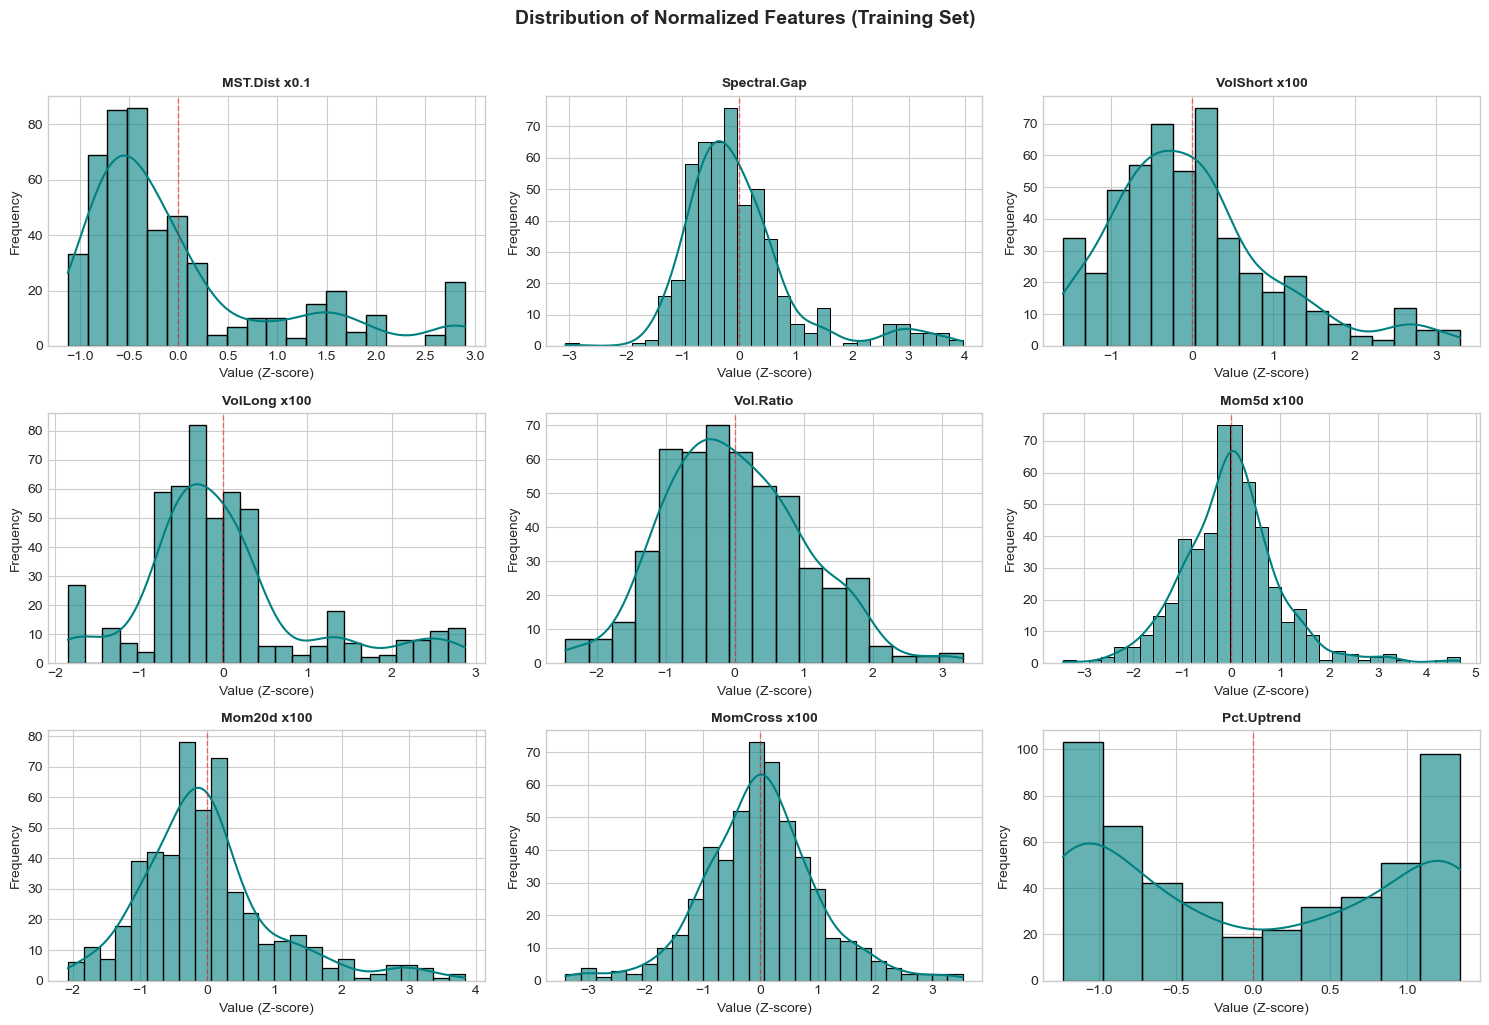

Summary Statistics (Normalized):


,mean,std,min,max
MST.Dist x0.1,-6.357829e-07,1.000994,-1.121371,2.901813
Spectral.Gap,-9.385366e-07,1.000994,-3.071687,3.956040
VolShort x100,-1.120189e-06,1.000993,-1.589430,3.297937
VolLong x100,-8.931236e-07,1.000994,-1.846012,2.872459
Vol.Ratio,-4.238553e-07,1.000994,-2.452231,3.298336
Mom5d x100,1.513769e-08,1.000993,-3.439487,4.682428
Mom20d x100,1.362392e-07,1.000994,-2.071388,3.835279
MomCross x100,-5.676633e-09,1.000994,-3.395267,3.522531
Pct.Uptrend,2.800472e-07,1.000995,-1.234854,1.342827


In [10]:
def plot_feature_distributions():
    norm_list = []
    # Menggunakan config yang mengaktifkan kedua jenis fitur
    dist_config = {'use_network': True, 'use_market': True}
    
    for i in range(SET_WINDOW, len(ret_train)):
        c = GLOBAL_CACHE[('train', i)]
        obs, _ = build_observation(None, dist_config, c['nw_feat_full'], c['corr_f'], c['mkt_feat_full'])
        norm_list.append(obs)
    
    df_norm = pd.DataFrame(norm_list, columns=FEATURE_NAMES)
    
    plt.figure(figsize=(15, 10))
    for i, col in enumerate(FEATURE_NAMES):
        plt.subplot(3, 3, i+1)
        sns.histplot(df_norm[col], kde=True, color='teal', alpha=0.6)
        plt.axvline(0, color='red', linestyle='--', linewidth=1, alpha=0.5)
        plt.title(f'{col}', fontsize=10, fontweight='bold')
        plt.xlabel('Value (Z-score)')
        plt.ylabel('Frequency')
    
    plt.suptitle('Distribution of Normalized Features (Training Set)', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    print("Summary Statistics (Normalized):")
    display(df_norm.describe().T[['mean', 'std', 'min', 'max']])

plot_feature_distributions()

## 9. RL Environment

In [11]:
class AblationPortfolioEnv(gym.Env):
    """
    Gymnasium environment untuk ablation study portfolio optimization.

    Action      : gamma scalar dalam [-5, 5].
    Observation : fitur (network + market) yang telah dinormalisasi.
    Reward      : risk-return metric (Sharpe/Sortino/Calmar/Ulcer),
                  dinormalisasi online Welford per episode.

    FIX:
    - Parameter split='train'/'test' menggantikan data_start_offset integer.
    - _rew_stats di-reset di reset() agar tidak ada bias akumulasi lintas episode.
    """

    def __init__(self, data, config, split='train'):
        super().__init__()
        self.data   = data
        self.config = config
        self.split  = split
        self.current_step    = SET_WINDOW
        self._returns_buffer = []
        self._reset_rew_stats()

        dim = get_obs_dim(config)
        self.action_space      = spaces.Box(low=-5.0, high=5.0, shape=(1,), dtype=np.float32)
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(dim,), dtype=np.float32)

    def _reset_rew_stats(self):
        self._rew_stats = {'mean': 0.0, 'M2': 0.0, 'count': 0}

    def _get_obs(self):
        c = GLOBAL_CACHE[(self.split, self.current_step)]
        # [v4] Teruskan mkt_feat_full agar build_observation tidak menghitung ulang
        obs, _ = build_observation(c['win'], self.config, c['nw_feat_full'], c['corr_f'], c['mkt_feat_full'])
        return obs

    def reset(self, seed=None, options=None):
        self.current_step    = SET_WINDOW
        self._returns_buffer = []
        self._reset_rew_stats()  # FIX: reset per episode
        return self._get_obs(), {}

    def step(self, action):
        gamma = float(np.clip(action[0], -5.0, 5.0))
        c     = GLOBAL_CACHE[(self.split, self.current_step)]
        w     = fast_centrality_weights(c['cov_f'], c['cent_vec'], c['mu'], gamma)

        port_ret = np.dot(w, self.data.iloc[self.current_step].values)
        self._returns_buffer.append(port_ret)
        if len(self._returns_buffer) > REWARD_WINDOW:
            self._returns_buffer.pop(0)

        arr         = np.array(self._returns_buffer)
        reward_type = self.config.get('reward_type', 'calmar')

        if len(arr) < 2:
            raw_reward = port_ret * 100
        else:
            if reward_type == 'sharpe':
                raw_reward = float(np.clip(calculate_sharpe_ratio(arr),  -10.0, 10.0))
            elif reward_type == 'sortino':
                raw_reward = float(np.clip(calculate_sortino_ratio(arr), -10.0, 10.0))
            elif reward_type == 'calmar':
                raw_reward = float(np.clip(calculate_calmar_ratio(arr),  -10.0, 10.0))
            elif reward_type == 'ulcer':
                ann_ret = calculate_annualized_return(arr)
                ulcer   = calculate_ulcer_index(arr)
                raw_reward = float(np.clip(ann_ret / (ulcer + 1e-8), -10.0, 10.0))
            else:
                raw_reward = 0.0

        # Online Welford variance normalization (di-reset per episode)
        s = self._rew_stats
        s['count'] += 1
        delta      = raw_reward - s['mean']
        s['mean'] += delta / s['count']
        s['M2']   += delta * (raw_reward - s['mean'])
        std    = np.sqrt(s['M2'] / s['count']) if s['count'] > 1 else 1.0
        reward = float(np.clip(raw_reward / (std + 1e-6), -10.0, 10.0))

        self.current_step += 1
        done     = self.current_step >= len(self.data) - 1
        next_obs = (self._get_obs() if not done
                    else np.zeros(self.observation_space.shape, dtype=np.float32))
        return next_obs, reward, done, False, {}


## 10. Training

> **[v5 — FIX #1] Model Selection via Validation Set (tidak lagi test set)**
>
> `EvalCallback` kini menggunakan **`ret_val` (validation set)**, bukan `ret_test`.
> Pipeline yang benar:
> ```
> ret_train → SAC.learn() → EvalCallback(ret_val) → simpan best model
>                                                         ↓
>                                              evaluasi akhir di ret_test
> ```
> Sebelumnya `EvalCallback` memakai `ret_test` langsung, menyebabkan:
> - **Look-ahead bias**: model "melihat" distribusi test set selama training
> - **Model selection bias**: model terbaik dipilih berdasarkan test set performa
> - Hasil evaluasi menjadi optimistis secara tidak fair


Experiments:   0%|          | 0/8 [00:00<?, ?it/s]

Seeds for E2_Sharpe:   0%|          | 0/3 [00:00<?, ?it/s]

Output()

Output()

Output()

...

Output()

Seeds for E2_Ulcer:   0%|          | 0/3 [00:00<?, ?it/s]

Output()

Output()

Output()

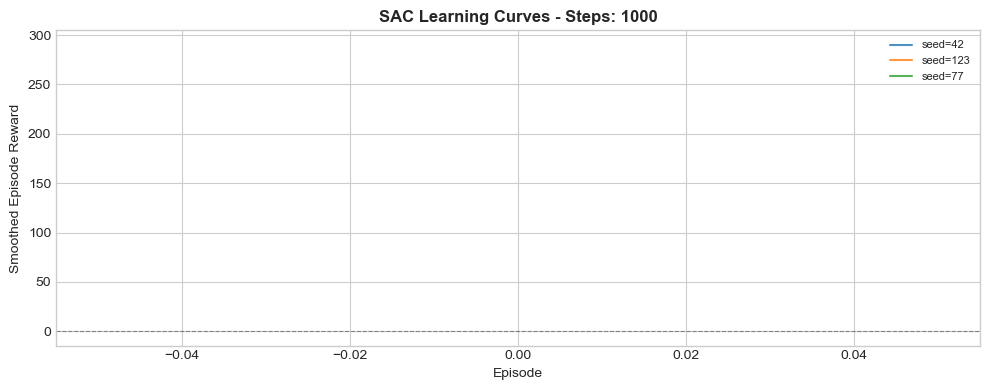

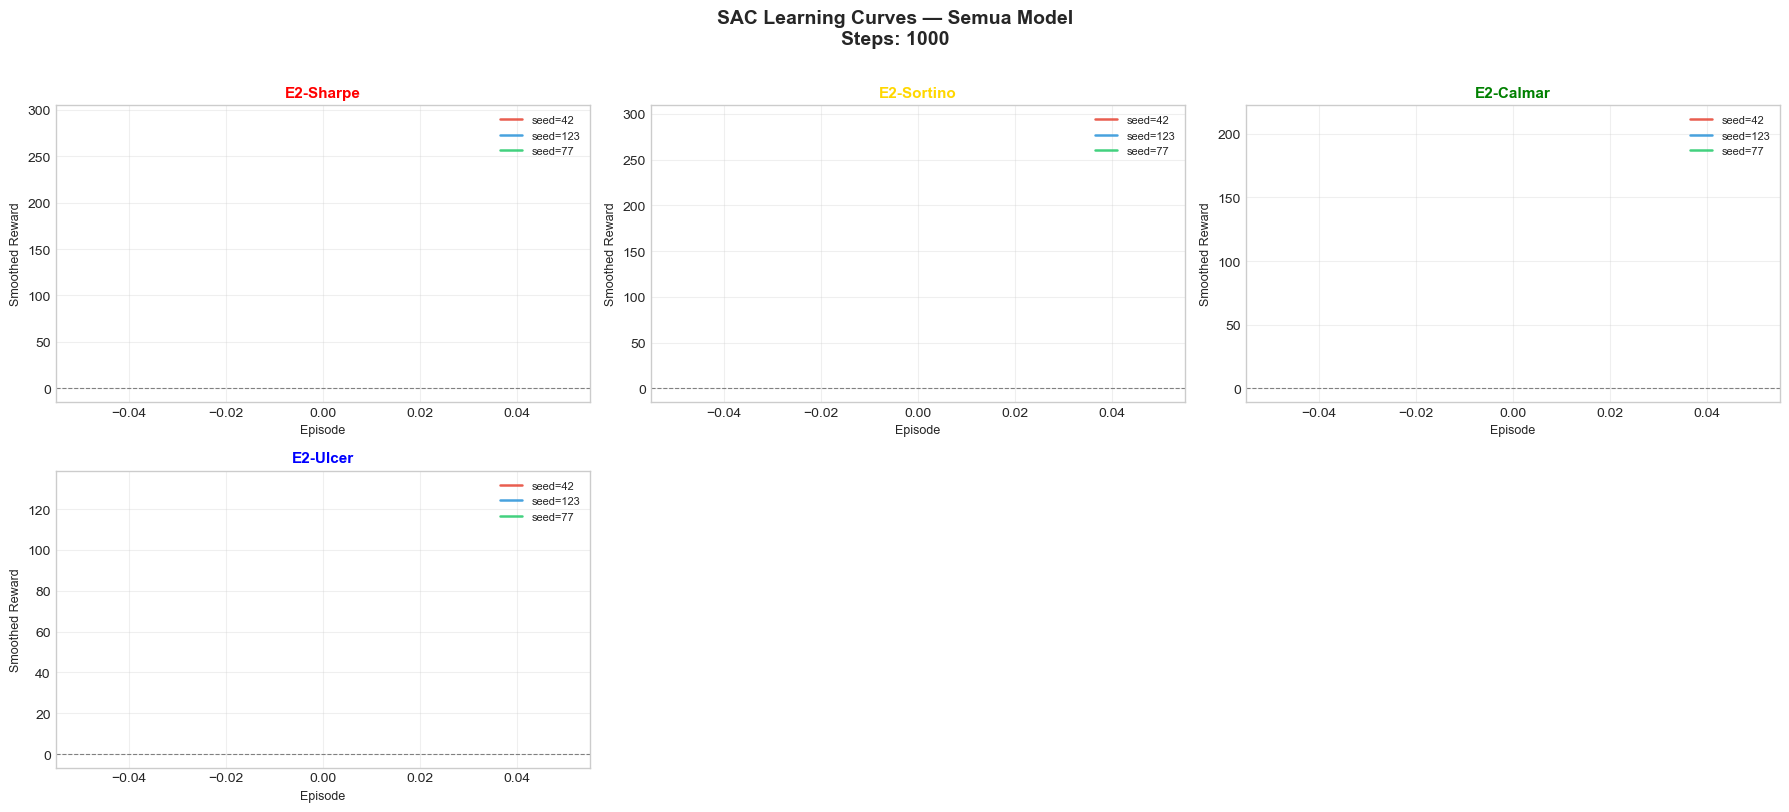

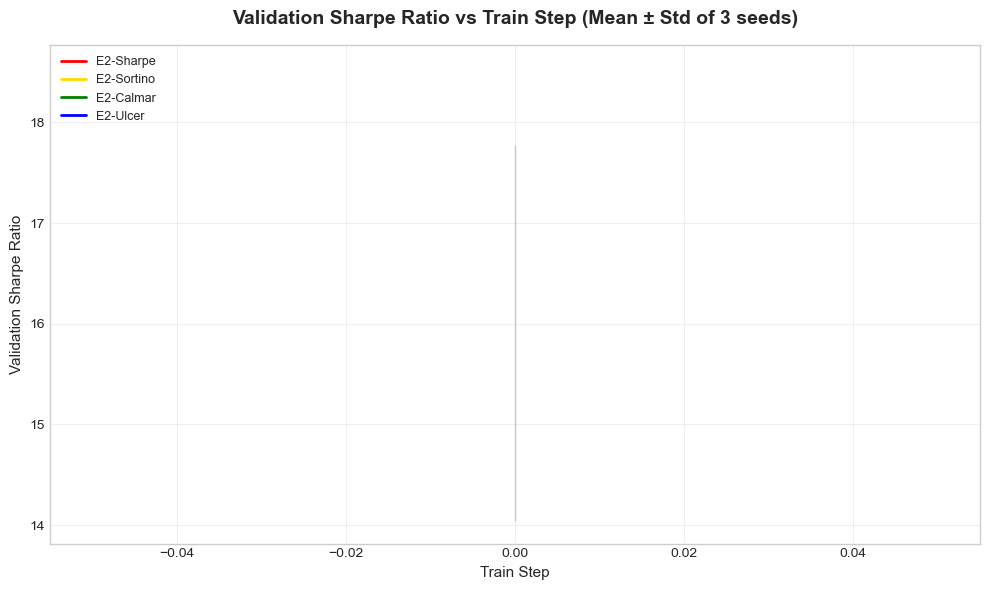

Training selesai.


In [12]:
trained_models  = {}
train_histories = {}
sharpe_histories = {}

exp_bar = tqdm(ABLATION_CONFIGS.items(), desc='Experiments')
for exp_id, config in exp_bar:
    # Skip static gamma dan ensemble (tidak ada RL training)
    if config.get('static_gamma') is not None or config.get('is_ensemble') or config.get('is_buyhold') or config.get('is_equal_weight'):
        continue

    train_histories[exp_id] = {}
    sharpe_histories[exp_id] = {}
    seed_bar = tqdm(SEEDS, desc=f'Seeds for {exp_id}', leave=False)

    for seed in seed_bar:
        name = f'model_{exp_id}_s{seed}'
        if os.path.exists(name + '.zip') and not FORCE_RETRAIN:
            trained_models[(exp_id, seed)] = name
            print(f'  Loaded existing: {name}')
            continue

        # [v5 FIX #1] EvalCallback menggunakan VALIDATION set, bukan test set.
        # Sebelumnya (v4): eval_env = AblationPortfolioEnv(ret_test, ..., split='test')
        #   → model selection bias: model terbaik dipilih berdasarkan test set.
        # Sekarang (v5): eval_env = AblationPortfolioEnv(ret_val, ..., split='val')
        #   → model selection menggunakan validation set yang benar-benar terpisah.
        env      = AblationPortfolioEnv(ret_train, config, split='train')
        eval_env = AblationPortfolioEnv(ret_val,   config, split='val')   # [v5] val set
        callback = RewardLoggerCallback()
        eval_callback = EvalCallback(eval_env, eval_freq=5000, deterministic=True, verbose=0)
        sharpe_eval_env = AblationPortfolioEnv(ret_val, config, split='val')
        sharpe_callback = SharpeLoggerCallback(sharpe_eval_env, eval_freq=5000)
        model = SAC(
            'MlpPolicy', env,
            seed=seed,
            verbose=0,
            learning_rate=1e-4,       # lebih konservatif untuk finansial
            buffer_size=50_000,        # replay buffer lebih besar
            batch_size=256,
            tau=0.005,
            gamma=0.99,
            ent_coef='auto',           # sudah default, tapi pastikan aktif
            policy_kwargs=dict(
                net_arch=[128, 128]    # network yang cukup untuk 9 fitur
            )
        )
        model.learn(total_timesteps=TRAIN_STEPS, callback=[callback, eval_callback, sharpe_callback], progress_bar=True)

        model.save(name)
        trained_models[(exp_id, seed)]  = name
        train_histories[exp_id][seed]   = callback.episode_rewards
        sharpe_histories[exp_id][seed]  = {'steps': sharpe_callback.eval_steps, 'sharpes': sharpe_callback.eval_sharpes}

if 'E2_Sharpe' in train_histories:
    plot_learning_curves(train_histories['E2_Sharpe'])  # learning curve model tunggal (backward compat)

# Plot learning curve SEMUA model yang di-training
plot_all_learning_curves(train_histories)

# Plot validation Sharpe Ratio vs Train Step untuk semua model
plot_all_sharpe_curves(sharpe_histories)

print('Training selesai.')




## 11. Backtesting Loop

In [13]:
results_test  = {}
results_train = {}

all_exp_ids = list(ABLATION_CONFIGS.keys()) + ['Classic-MV']  # BuyHold_Markowitz sudah ada di ABLATION_CONFIGS

for exp_id in tqdm(all_exp_ids, desc='Backtesting'):
    results_test[exp_id]  = pd.DataFrame()
    results_train[exp_id] = pd.DataFrame()
    config = ABLATION_CONFIGS.get(exp_id, {})

    for seed in SEEDS:
        model           = None
        ensemble_models = []

        if exp_id != 'Classic-MV' and config.get('static_gamma') is None and not config.get('is_buyhold') and not config.get('is_equal_weight'):
            if config.get('is_ensemble'):
                for m_id in ['E2_Sharpe', 'E2_Sortino', 'E2_Calmar', 'E2_Ulcer']:
                    ensemble_models.append(SAC.load(trained_models[(m_id, seed)]))
            else:
                model = SAC.load(trained_models[(exp_id, seed)])

        # ── Buy&Hold-Markowitz: hitung bobot awal sekali, lalu drift ──────────
        if config.get('is_buyhold'):
            def _make_buyhold_rets(data_df, split_key):
                """
                [v5 FIX #2] Bobot awal selalu dihitung dari window TERAKHIR training set,
                bukan dari window pertama data_df.

                Bug sebelumnya (v4):
                    c0 = GLOBAL_CACHE[(split_key, SET_WINDOW)]
                    Untuk split_key='test', ini menggunakan window pertama data TEST
                    → data leakage: investor seolah sudah tahu distribusi aset di awal
                      test period sebelum periode itu benar-benar dimulai.

                Fix (v5):
                    c0 = GLOBAL_CACHE[('train', last_train_idx)]
                    Bobot selalu diinisialisasi dari informasi akhir training period,
                    konsisten secara temporal untuk semua split (train maupun test).

                Setelah inisialisasi, bobot dibiarkan drift alami (no rebalancing).
                Ini mensimulasikan investor yang menetapkan alokasi di akhir training,
                lalu tidak melakukan rebalancing selama test period.
                """
                # [v5] Inisialisasi dari window TERAKHIR training (bukan awal test)
                last_train_idx = len(ret_train) - 1
                c0  = GLOBAL_CACHE[('train', last_train_idx)]
                w   = fast_centrality_weights(c0['cov_f'], c0['cent_vec'],
                                              c0['mu'], gamma=1.0)   # dari end-of-train
                rets = []
                for idx in range(SET_WINDOW, len(data_df)):
                    r_vec    = data_df.iloc[idx].values
                    port_ret = float(np.dot(w, r_vec))
                    rets.append(port_ret)
                    # drift: biarkan bobot bergerak mengikuti return aset, tanpa rebalancing
                    w = w * (1 + r_vec)
                    total = w.sum()
                    if total > 1e-10:
                        w = w / total          # normalisasi nilai (bukan rebalancing)
                    else:
                        w = np.ones(len(w)) / len(w)  # fallback jika collapse
                return rets

            rets_test  = _make_buyhold_rets(ret_test,  'test')
            rets_train = _make_buyhold_rets(ret_train, 'train')
            results_test[exp_id][seed]  = pd.Series(rets_test,
                                                     index=ret_test.index[SET_WINDOW:])
            results_train[exp_id][seed] = pd.Series(rets_train,
                                                     index=ret_train.index[SET_WINDOW:])
            continue   # skip sisa loop (tidak perlu get_weights)

        def get_weights(split, step_idx):
            c = GLOBAL_CACHE[(split, step_idx)]
            if exp_id == 'Classic-MV':
                return compute_classic_mv_weights(c['win'])
            if config.get('is_equal_weight'):
                return np.ones(len(assets)) / len(assets)
            if config.get('static_gamma') is not None:
                return fast_centrality_weights(c['cov_f'], c['cent_vec'],
                                               c['mu'], config['static_gamma'])
            obs, _ = build_observation(c['win'], config, c['nw_feat_full'], c['corr_f'], c['mkt_feat_full'])  # [v4]
            if config.get('is_ensemble'):
                gammas = [float(em.predict(obs, deterministic=True)[0][0])
                          for em in ensemble_models]
                return fast_centrality_weights(c['cov_f'], c['cent_vec'],
                                               c['mu'], np.mean(gammas))
            action, _ = model.predict(obs, deterministic=True)
            return fast_centrality_weights(c['cov_f'], c['cent_vec'],
                                           c['mu'], float(action[0]))  # [v4] obs sudah dinormalisasi

        # --- Testing ---
        rets_test = [
            np.dot(get_weights('test', i), ret_test.iloc[i].values)
            for i in range(SET_WINDOW, len(ret_test))
        ]
        results_test[exp_id][seed] = pd.Series(
            rets_test, index=ret_test.index[SET_WINDOW:])

        # --- Training (evaluasi ulang, bukan training) ---
        rets_train_eval = [
            np.dot(get_weights('train', i), ret_train.iloc[i].values)
            for i in range(SET_WINDOW, len(ret_train))
        ]
        results_train[exp_id][seed] = pd.Series(
            rets_train_eval, index=ret_train.index[SET_WINDOW:])

print('Backtesting selesai.')





Backtesting:   0%|          | 0/9 [00:00<?, ?it/s]

Backtesting selesai.


## 12. Final Analysis, Wilcoxon Tests & SHAP


=== Generating Final Dashboards ===


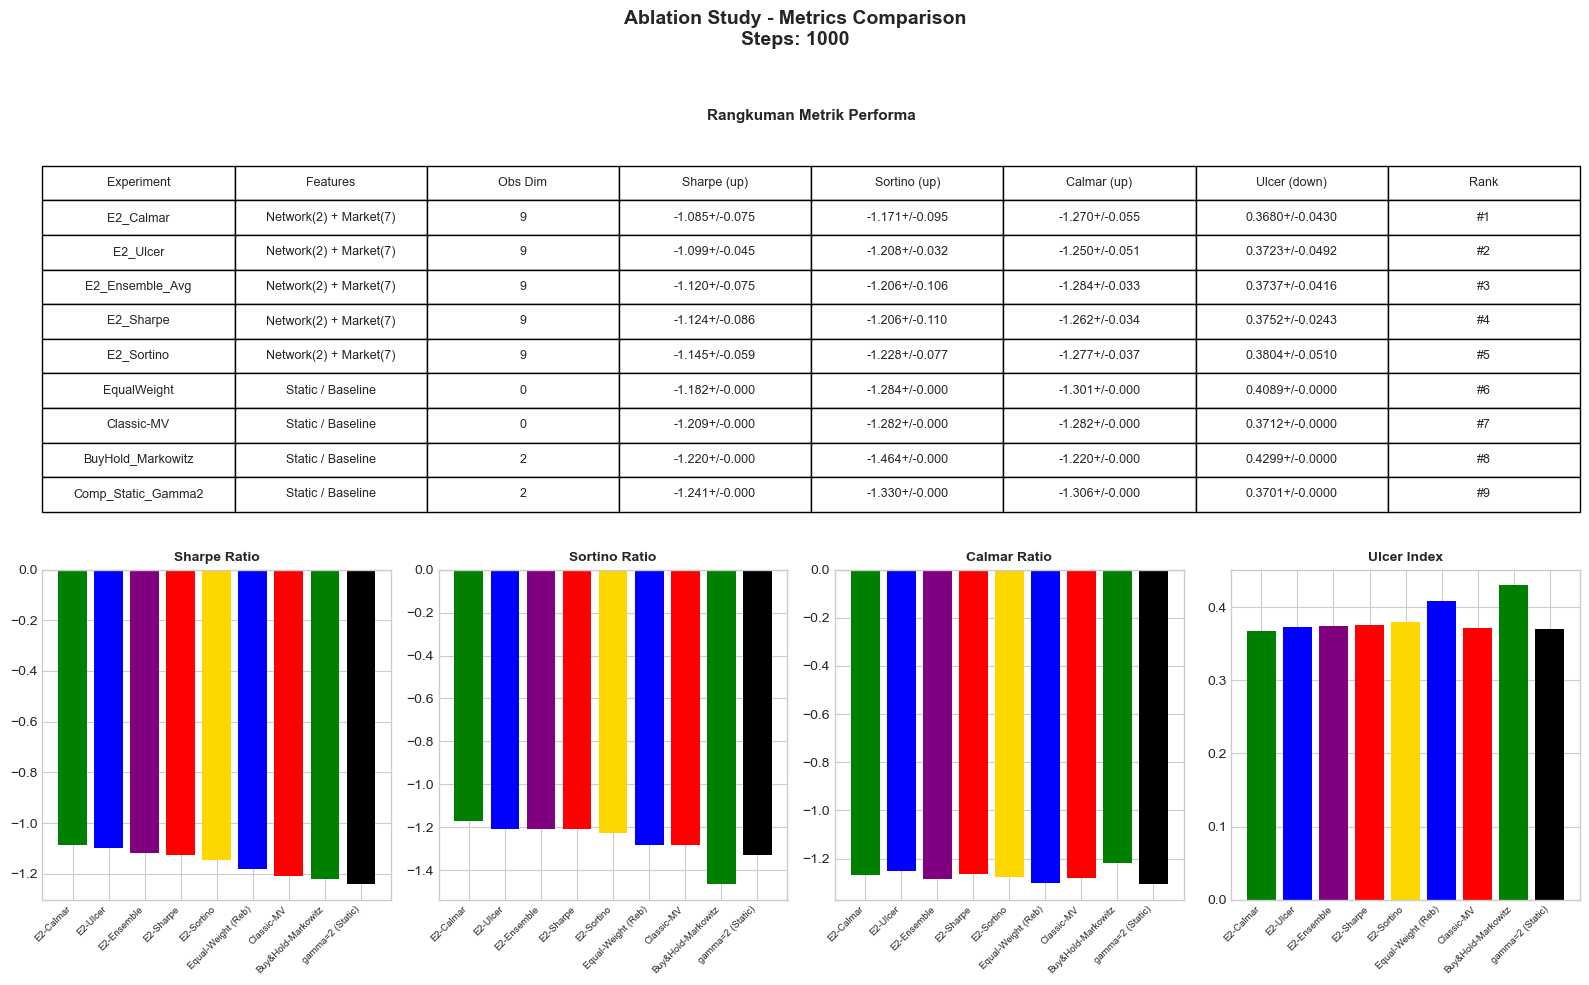

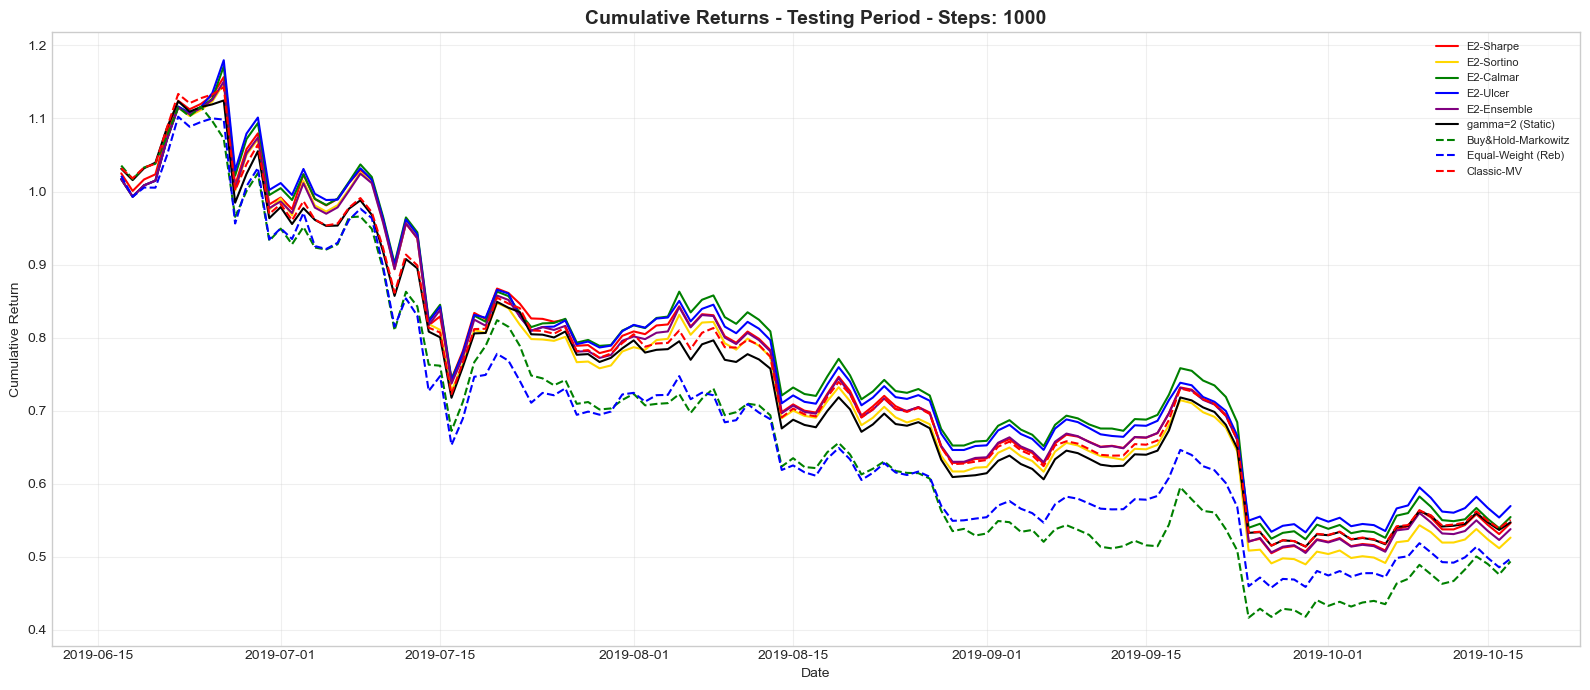

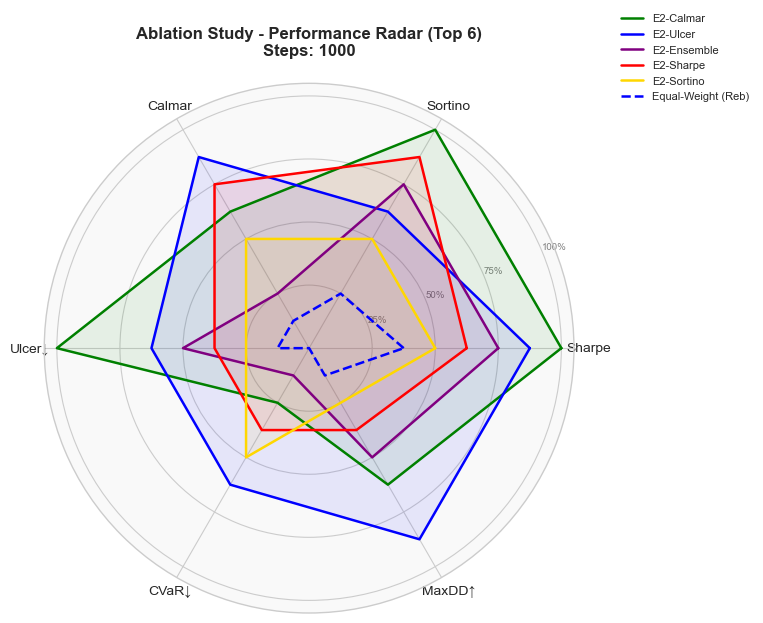

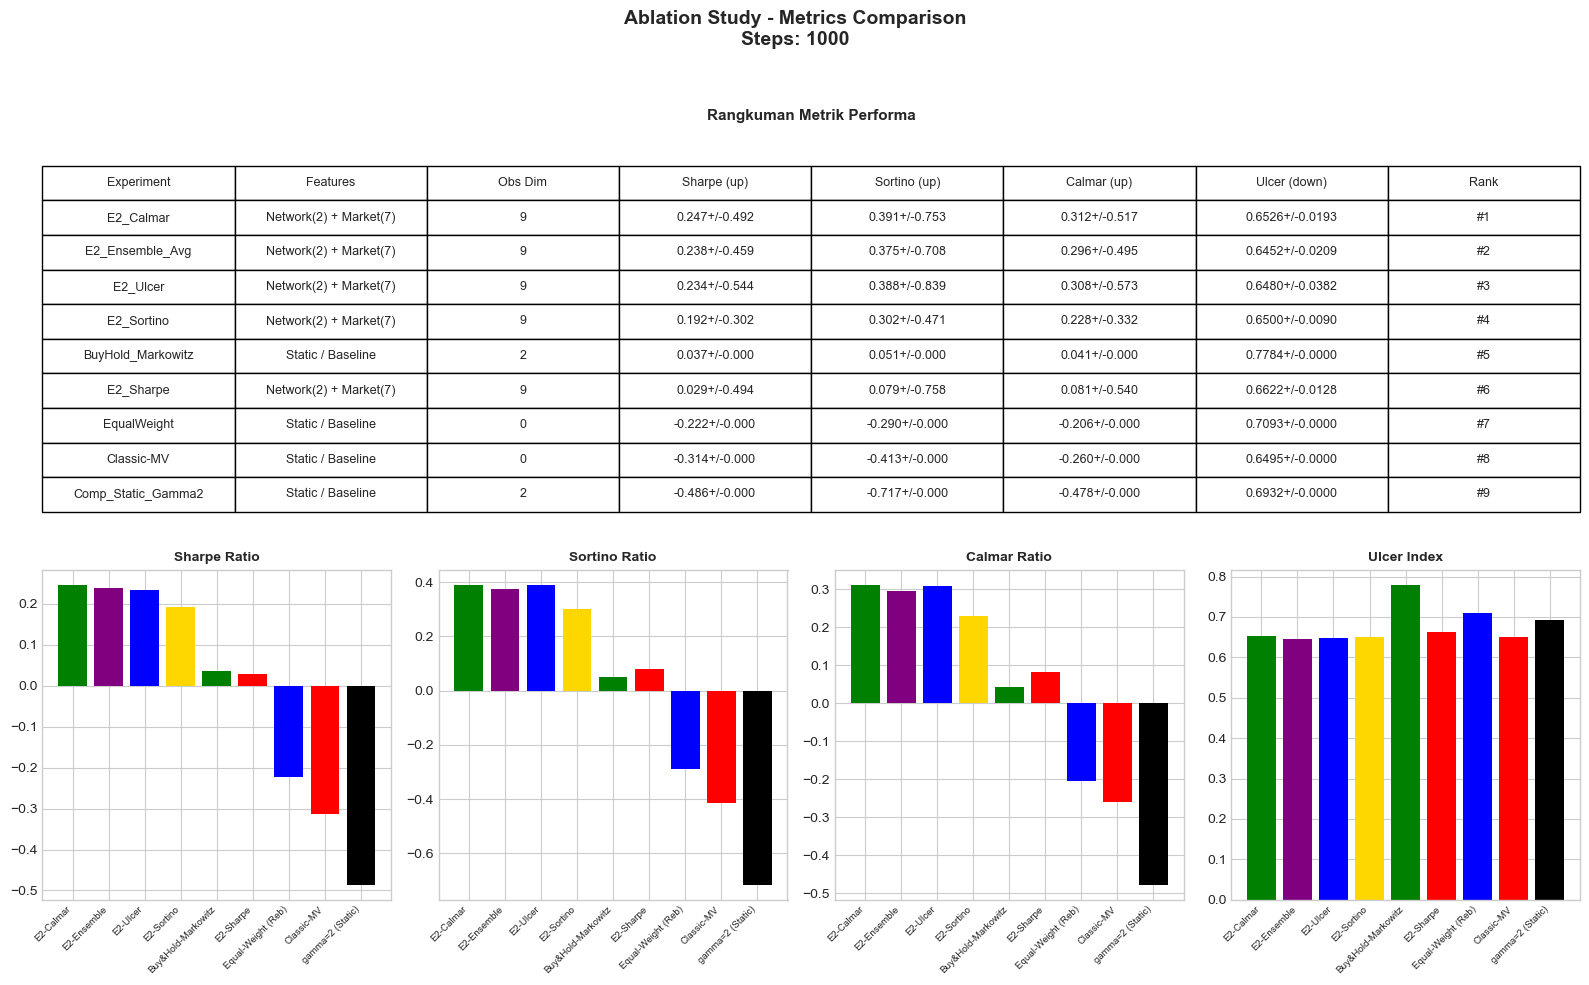

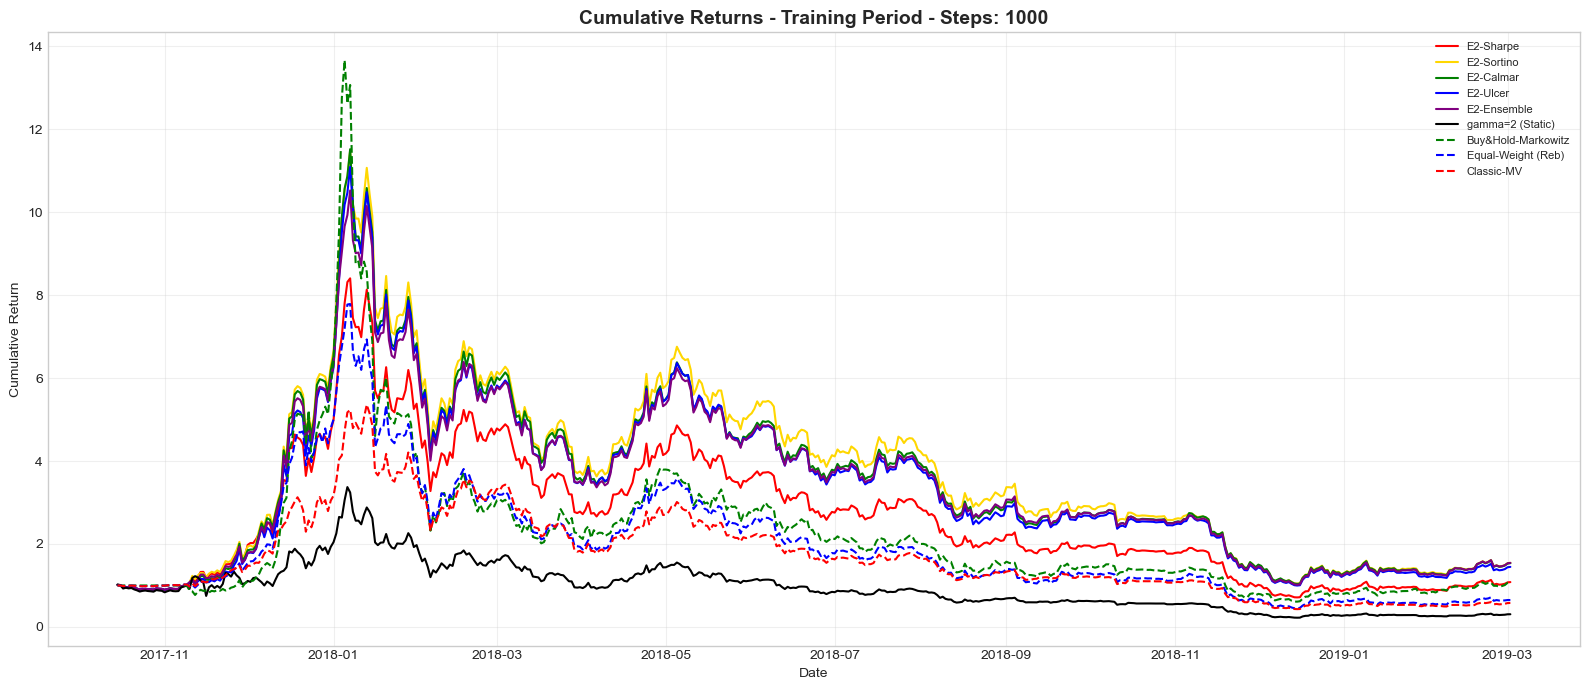

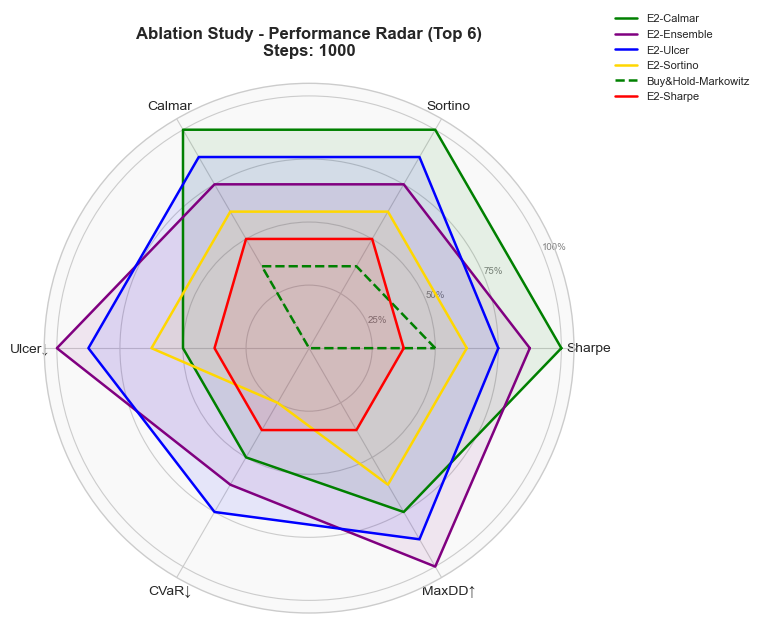


=== Wilcoxon Signed-Rank Tests (vs Classic-MV, Testing Period) ===
  E2_Sharpe             : p = 0.7012 
  E2_Sortino            : p = 0.3200 
  E2_Calmar             : p = 0.8282 
  E2_Ulcer              : p = 0.5463 
  E2_Ensemble_Avg       : p = 0.8282 
  Comp_Static_Gamma2    : p = 0.0409 *
  BuyHold_Markowitz     : p = 0.2571 
  EqualWeight           : p = 0.4120 
  (* = signifikan pada alpha=0.05)

=== Generating SHAP Analysis ===
  Generating SHAP for E2_Sharpe...


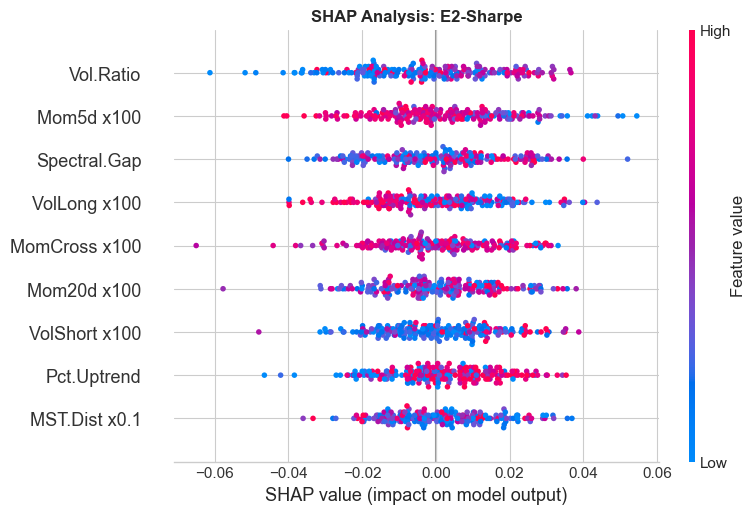

  Generating SHAP for E2_Sortino...


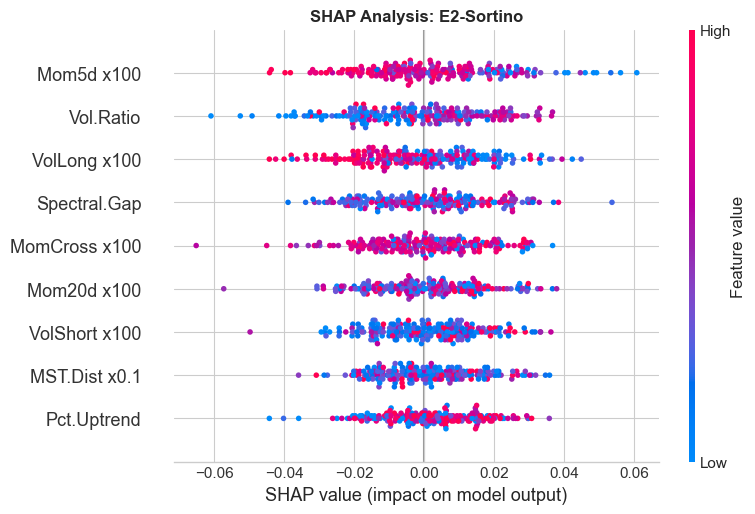

  Generating SHAP for E2_Calmar...


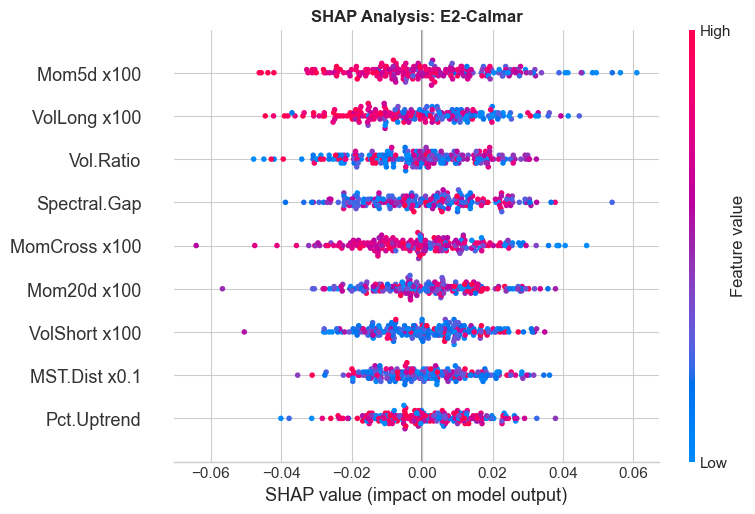

  Generating SHAP for E2_Ulcer...


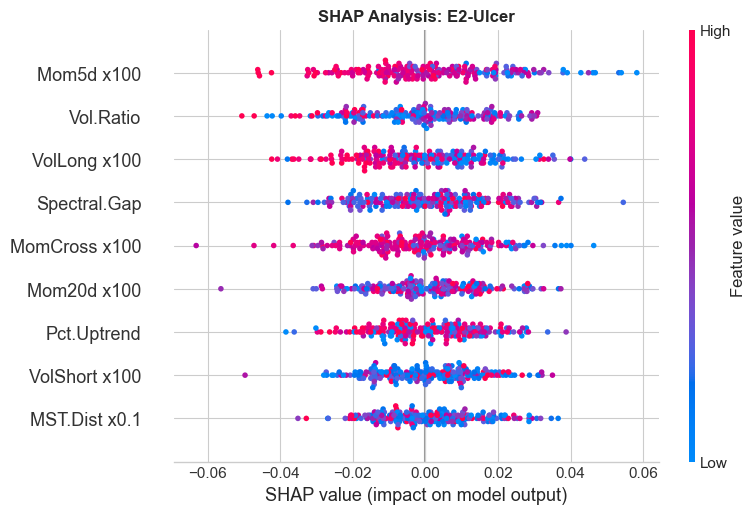

  Generating SHAP for E2_Ensemble_Avg...


ExactExplainer explainer: 201it [00:13,  3.82it/s]                         


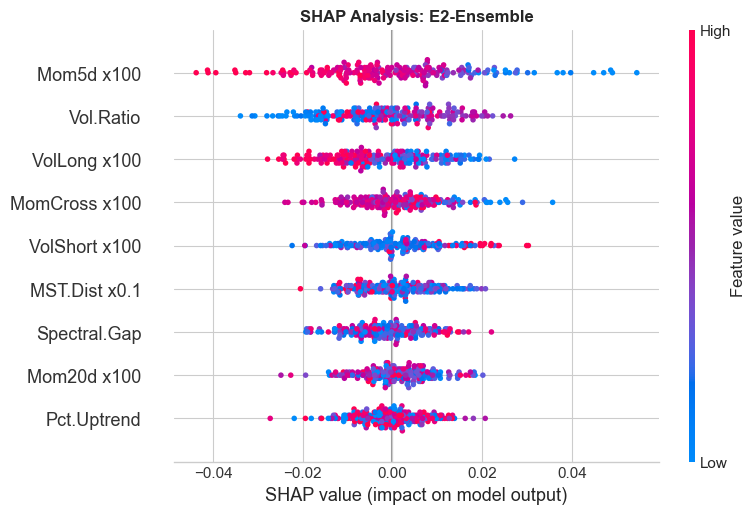


Analisis selesai.


In [14]:
print('\n=== Generating Final Dashboards ===')
generate_dashboard(results_test,  'Ablation Study', 'Testing',  'testing.png')
generate_dashboard(results_train, 'Ablation Study', 'Training', 'training.png')

# FIX: run_wilcoxon_tests sekarang benar-benar dipanggil + hasil ditampilkan
print('\n=== Wilcoxon Signed-Rank Tests (vs Classic-MV, Testing Period) ===')
pvals = run_wilcoxon_tests(results_test, baseline_id='Classic-MV')
for exp_id, p in pvals.items():
    sig = '*' if (not np.isnan(p) and p < STAT_ALPHA) else ''
    pstr = f'{p:.4f}' if not np.isnan(p) else 'NaN'
    print(f'  {exp_id:<22}: p = {pstr} {sig}')
print(f'  (* = signifikan pada alpha={STAT_ALPHA})')

print('\n=== Generating SHAP Analysis ===')
seed0 = SEEDS[0]
for exp_id in ['E2_Sharpe', 'E2_Sortino', 'E2_Calmar', 'E2_Ulcer', 'E2_Ensemble_Avg']:
    config = ABLATION_CONFIGS.get(exp_id, {})
    if exp_id == 'E2_Ensemble_Avg':
        m_paths = [trained_models.get((m, seed0))
                   for m in ['E2_Sharpe', 'E2_Sortino', 'E2_Calmar', 'E2_Ulcer']]
    else:
        m_paths = trained_models.get((exp_id, seed0))
    env_shap = AblationPortfolioEnv(ret_test, config, split='test')
    plot_shap_analysis(m_paths, env_shap, config, exp_id)

print('\nAnalisis selesai.')



## 13. Enhanced Analysis — Rolling Window, Bootstrap CI, Regime, Turnover, Extra Baselines

Penambahan eksperimen lanjutan (tanpa menghapus kode apapun):
- **13A** Rolling Sharpe/Sortino/CVaR (60-hari) tiap strategi
- **13B** Bootstrap Confidence Intervals (N=2000) untuk semua metrik
- **13C** Market Regime Detection (HMM-proxy via volatility clustering)
- **13D** Portfolio Turnover & Transaction Cost Analysis (0 / 10 / 30 bps)
- **13E** Additional Baselines: Equal Weight & Inverse Volatility
- **13F** Strategy Return Correlation Heatmap
- **13G** Underwater (Drawdown) Plot yang lebih detail


## 14. Thesis-Grade Sharpening — Statistical Rigor, Generalization & Interpretability

Penambahan terakhir untuk memperkuat klaim thesis secara akademis:
- **14A** Diebold-Mariano Test — uji signifikansi forecast loss antar strategi
- **14B** Walk-Forward Validation (expanding window) — anti data snooping
- **14C** Gamma Distribution Analysis — visualisasi distribusi aksi RL
- **14D** Concentration & HHI Analysis — seberapa terdiversifikasi portofolio
- **14E** Information Ratio vs Benchmark — metrik standar fund management
- **14F** Cross-Seed Stability Test — apakah hasil stabil di berbagai seed?
- **14G** Efficient Frontier Overlay — posisi strategi di peta risk-return
- **14H** LaTeX-Ready Summary Table — siap paste ke thesis


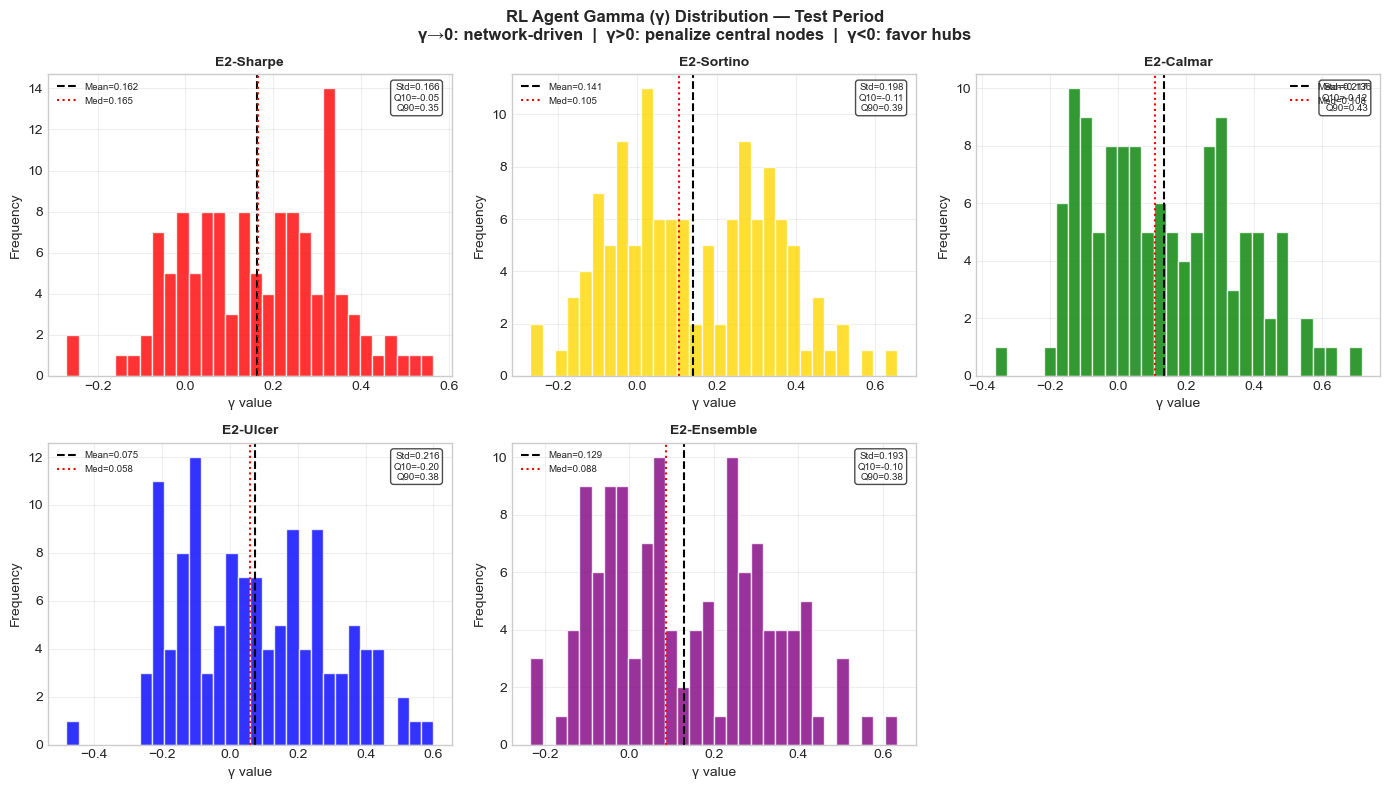

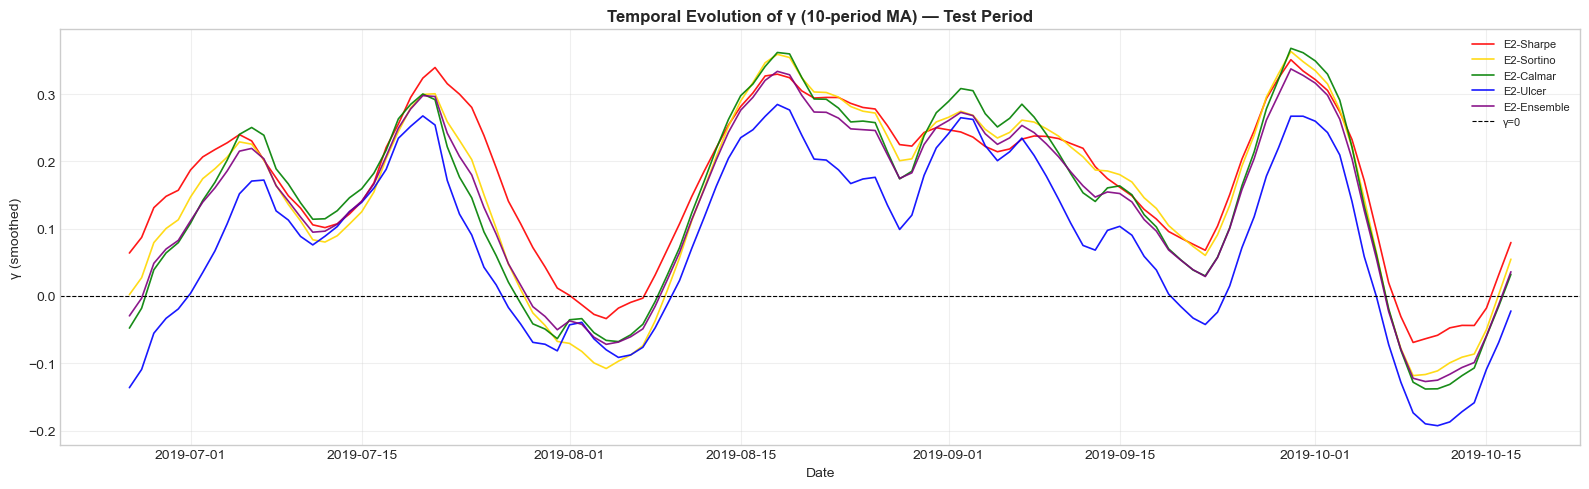

14C Gamma Distribution Analysis selesai.


In [25]:
# ═══════════════════════════════════════════════════════════════════════
# 14C. Gamma (Action) Distribution Analysis
# ═══════════════════════════════════════════════════════════════════════
# Visualisasi distribusi gamma yang dipilih RL agent selama test period.
# Menjawab: apakah agent belajar gamma yang stabil atau sangat fluktuatif?

rl_exp_ids = [eid for eid, cfg in ABLATION_CONFIGS.items()
              if cfg.get('static_gamma') is None and not cfg.get('is_buyhold') and not cfg.get('is_equal_weight')]

gamma_distributions = {}
for exp_id in rl_exp_ids:
    config = ABLATION_CONFIGS[exp_id]
    seed   = SEEDS[0]
    try:
        if config.get('is_ensemble'):
            # Load all sub-models
            sub_models = [SAC.load(trained_models[(m, seed)])
                          for m in ['E2_Sharpe', 'E2_Sortino', 'E2_Calmar', 'E2_Ulcer']]
            gammas = []
            for i in range(SET_WINDOW, len(ret_test)):
                c = GLOBAL_CACHE.get(('test', i))
                if c is None: continue
                obs, _ = build_observation(c['win'], config, c['nw_feat_full'], c['corr_f'], c['mkt_feat_full'])
                # Average actions from all sub-models
                sub_acts = [float(sm.predict(obs, deterministic=True)[0][0]) for sm in sub_models]
                gammas.append(np.mean(sub_acts))
        else:
            model = SAC.load(trained_models[(exp_id, seed)])
            gammas = []
            for i in range(SET_WINDOW, len(ret_test)):
                c = GLOBAL_CACHE.get(('test', i))
                if c is None: continue
                obs, _ = build_observation(c['win'], config, c['nw_feat_full'], c['corr_f'], c['mkt_feat_full'])
                action, _ = model.predict(obs, deterministic=True)
                gammas.append(float(action[0]))
        gamma_distributions[exp_id] = np.array(gammas)
    except Exception as ex:
        print(f'  Skip {exp_id}: {ex}')

if gamma_distributions:
    n_plots = len(gamma_distributions)
    fig, axes = plt.subplots(2, (n_plots+1)//2, figsize=(14, 8), facecolor='white')
    axes = axes.flatten()
    fig.suptitle('RL Agent Gamma (γ) Distribution — Test Period\n'
                 'γ→0: network-driven  |  γ>0: penalize central nodes  |  γ<0: favor hubs',
                 fontsize=12, fontweight='bold')

    for ax, (exp_id, gammas) in zip(axes, gamma_distributions.items()):
        color = ABLATION_COLORS.get(exp_id, '#777777')
        ax.hist(gammas, bins=30, color=color, alpha=0.8, edgecolor='white')
        ax.axvline(gammas.mean(),  color='black', linestyle='--', linewidth=1.5,
                   label=f'Mean={gammas.mean():.3f}')
        ax.axvline(np.median(gammas), color='red', linestyle=':', linewidth=1.5,
                   label=f'Med={np.median(gammas):.3f}')
        ax.set_title(get_display_name(exp_id), fontsize=10, fontweight='bold')
        ax.set_xlabel('γ value'); ax.set_ylabel('Frequency')
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)

        # Annotate stats
        stats_txt = (f'Std={gammas.std():.3f}\n'
                     f'Q10={np.percentile(gammas,10):.2f}\n'
                     f'Q90={np.percentile(gammas,90):.2f}')
        ax.text(0.97, 0.97, stats_txt, transform=ax.transAxes,
                fontsize=7, va='top', ha='right',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

    for ax in axes[len(gamma_distributions):]:
        ax.set_visible(False)
    plt.tight_layout()
    if SAVE_IMAGES:
        plt.savefig(os.path.join(OUTPUT_DIR, '14C_gamma_distributions.png'), dpi=200)
    plt.show()
    plt.close()

    # ── Temporal gamma plot (time series of gamma choices) ─────────────────
    fig, ax = plt.subplots(figsize=(16, 5), facecolor='white')
    for exp_id, gammas in gamma_distributions.items():
        idx = ret_test.index[SET_WINDOW:SET_WINDOW+len(gammas)]
        ax.plot(idx, pd.Series(gammas, index=idx).rolling(10).mean(),
                label=get_display_name(exp_id),
                color=ABLATION_COLORS.get(exp_id, '#777777'), alpha=0.9, linewidth=1.2)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', label='γ=0')
    ax.set_title('Temporal Evolution of γ (10-period MA) — Test Period',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Date'); ax.set_ylabel('γ (smoothed)')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    if SAVE_IMAGES:
        plt.savefig(os.path.join(OUTPUT_DIR, '14C_gamma_temporal.png'), dpi=200)
    plt.show()
    plt.close()
print('14C Gamma Distribution Analysis selesai.')